# Feature-Effect Geometry Analysis with **Murano**

> *Sparse Autoencoders Encode Both Concepts and Functions: The Downstream Geometry of Feature Effects.*  
> Phu Gia Hoang, Anwoy Chatterjee, Tanmoy Chakraborty, Iryna Gurevych, Subhabrata Dutta. 2026.  
> [arXiv:2607.24645](https://arxiv.org/abs/2607.24645) · [FEGA source](https://github.com/UKPLab/FEGA)

Feature-Effect Geometry Analysis (FEGA) removes the same active sparse-autoencoder feature in several contexts and studies the resulting cloud of downstream logit effects. A feature may behave like one reusable direction, an axis, a low-dimensional subspace, several modes, or a diffuse cloud.

This notebook has two deliberately separate parts:

1. **Executable Murano run.** All six FEGA analysis phases plus visualization run on 24 authored city prompts.
2. **Compact source-geometry comparison.** Murano rerenders one retained example per reported geometry family from exported arrays and shows the copied source PNGs as labeled targets.

The notebook demonstrates the complete native Murano workflow. Its live conclusion applies only to the authored prompts; it does not recreate the paper's RAVEL/ICL datasets or experiment matrix.

**Requirements:** a CUDA GPU, Hugging Face access to Gemma 2, and the `murano-interp[fega]` extra.

## 1. Setup

In [1]:
# Install Murano and the FEGA dependencies on a fresh notebook runtime.
try:
    import murano  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "murano-interp[fega]"],
        check=True,
    )

In [2]:
import json
import tempfile
from pathlib import Path

import numpy as np
import torch
from IPython.display import Image, Markdown, display

from murano import DictionarySAEModel, Pipeline, fega_steps, keys
from murano.fega.visual_detail import (
    render_residual_view,
    render_subspace_plane,
    residual_point_colors,
)
from murano.fega.visualization import (
    CLASS_PALETTE,
    render_atlas,
    render_projection_2d,
    render_sphere_surface,
    surface_coordinates,
)
from murano.model import MuranoModel
from murano.steps.prompts import LoadPrompts

if not torch.cuda.is_available():
    raise RuntimeError("This Gemma-2 FEGA demonstration requires a CUDA GPU")

MODEL_ID = "google/gemma-2-2b"
SAE_REPO = "canrager/saebench_gemma-2-2b_width-2pow16_date-0107"
SAE_ID = "gemma-2-2b_standard_new_width-2pow16_date-0107/resid_post_layer_12/trainer_2"
FEATURE_ID = 19403

# Match the released Gemma recipe. The fixed batch size is recorded because
# reduced-precision model arithmetic can move individual effects slightly.
model = MuranoModel(
    MODEL_ID,
    dtype=torch.bfloat16,
    attn_implementation="eager",
)
sae = DictionarySAEModel(
    SAE_REPO,
    SAE_ID,
    MODEL_ID,
    device=str(model.unembed_weight.device),
    dtype=torch.bfloat16,
)
print(f"Loaded {MODEL_ID} and feature {FEATURE_ID} on {model.unembed_weight.device}")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded google/gemma-2-2b and feature 19403 on cuda:0


## 2. Authored prompt population

These 24 prompts were written for this notebook. Feature 19403 was chosen because it is active on this complete population; it is not presented as one of the paper's selected features. Every effect is measured at the final token after the colon.

In [3]:
prompts = [
    "city: Paris, country:",
    "city: Berlin, country:",
    "city: Lisbon, country:",
    "city: Vienna, country:",
    "city: Warsaw, country:",
    "city: Prague, country:",
    "city: Athens, country:",
    "city: Dublin, country:",
    "city: Oslo, country:",
    "city: Stockholm, country:",
    "city: Helsinki, country:",
    "city: Copenhagen, country:",
    "city: Brussels, country:",
    "city: Amsterdam, country:",
    "city: Zurich, country:",
    "city: Budapest, country:",
    "city: Bucharest, country:",
    "city: Sofia, country:",
    "city: Zagreb, country:",
    "city: Belgrade, country:",
    "city: Tallinn, country:",
    "city: Riga, country:",
    "city: Vilnius, country:",
    "city: Reykjavik, country:",
]
print(f"Authored prompt count: {len(prompts)}")

Authored prompt count: 24


## 3. Run native FEGA analysis and visualization

`fega_steps(phases="all")` runs, in order:

1. `data_prep`: tokenize, left-pad, encode with the SAE, and select active contexts;
2. `compute_effect`: compare the full SAE reconstruction with the same reconstruction after zeroing one feature;
3. `geometry_metrics`: measure the effect cloud in logit geometry;
4. `vmf`: fit the dense CPU directional mixtures;
5. `stability`: repeat the selected-family checks on deterministic subsets;
6. `geometry_reporting`: assign the geometry family and flags;
7. `visualize`: render the atlas, unit-sphere surface, and two-dimensional projection.

The temporary directory holds only live figures during execution. The notebook stores their rendered outputs below and removes the directory in the final check.

In [4]:
live_directory = tempfile.TemporaryDirectory(prefix="murano-fega-notebook-")
phase_keys = {
    "data_prep": keys.FEGA_DATA_PREP,
    "compute_effect": keys.FEGA_EFFECTS,
    "geometry_metrics": keys.FEGA_GEOMETRY,
    "vmf": keys.FEGA_VMF,
    "stability": keys.FEGA_STABILITY,
    "geometry_reporting": keys.FEGA_REPORTING,
    "visualize": keys.FEGA_VISUALIZATION,
}

results = Pipeline(
    [
        LoadPrompts(prompts),
        *fega_steps(
            model,
            release=SAE_REPO,
            sae_id=SAE_ID,
            sae_model=sae,
            feature_ids=[FEATURE_ID],
            phases="all",
            batch_size=len(prompts),
            max_contexts=len(prompts),
            n_jobs=1,
            top_k_per_family=1,
            figures=("atlas", "sphere_surface", "projection_2d"),
            output_dir=live_directory.name,
            dpi=120,
        ),
    ]
).run()

prep = results[keys.FEGA_DATA_PREP]
feature_effects = results[keys.FEGA_EFFECTS].features[FEATURE_ID]
geometry = results[keys.FEGA_GEOMETRY].features[FEATURE_ID]
vmf = results[keys.FEGA_VMF]
stability = results[keys.FEGA_STABILITY].features[FEATURE_ID]
classification = results[keys.FEGA_REPORTING].features[FEATURE_ID]
activations = feature_effects.feature_activations.float().cpu().numpy()
magnitudes = feature_effects.magnitudes.float().cpu().numpy()
selected_fit = vmf.features[FEATURE_ID].selected

live_summary_rows = [
    ("Authored prompts", str(len(prompts))),
    ("Contexts selected", str(len(prep.selected_context_indices[FEATURE_ID]))),
    ("Effects retained", str(len(feature_effects.context_indices))),
    (
        "Feature activation min / median / max",
        " / ".join(
            f"{value:.4g}"
            for value in (activations.min(), np.median(activations), activations.max())
        ),
    ),
    (
        "Effect magnitude min / median / max",
        " / ".join(
            f"{value:.4g}"
            for value in (magnitudes.min(), np.median(magnitudes), magnitudes.max())
        ),
    ),
]
display(
    Markdown(
        "### Live authored-population summary\n\n| Quantity | Value |\n| --- | ---: |\n"
        + "\n".join(f"| {name} | {value} |" for name, value in live_summary_rows)
    )
)

geometry_summary_rows = [
    ("$c_{ray}$", geometry.c_ray),
    ("$s_{span}(1)$", geometry.s_span.get(1)),
    ("$r_{span,PR}$", geometry.r_span_pr),
    ("$b_{axis}$", geometry.b_axis),
    ("$e_{res}$", geometry.e_res),
    ("$r_{ctr,PR}$", geometry.r_ctr_pr),
]
display(
    Markdown(
        "### Geometry metrics\n\n| Metric | Value |\n| --- | ---: |\n"
        + "\n".join(
            f"| {name} | {'—' if value is None else f'{value:.4f}'} |"
            for name, value in geometry_summary_rows
        )
    )
)

decision_summary_rows = [
    ("Selected mixture components", str(selected_fit.n_components)),
    ("Assignment stability", f"{vmf.assignment_stability[FEATURE_ID]:.4f}"),
    ("Geometry family", classification.primary_label),
    ("Stability decision", str(stability["decision"])),
    ("Confidence", str(classification.confidence)),
    ("Flags", ", ".join(classification.secondary_flags) or "none"),
]
display(
    Markdown(
        "### Mixture and final decision\n\n| Quantity | Value |\n| --- | --- |\n"
        + "\n".join(f"| {name} | {value} |" for name, value in decision_summary_rows)
    )
)

/mnt/beegfs/work/hoang/codecode/murano/src/murano/pipeline.py:71: RuntimeWarning: reduced-precision FEGA effect collection can be batch-sensitive; batch size is part of the result; float32 model weights reduced the observed sensitivity in the validated Gemma run
  results = step(results)


### Live authored-population summary

| Quantity | Value |
| --- | ---: |
| Authored prompts | 24 |
| Contexts selected | 24 |
| Effects retained | 24 |
| Feature activation min / median / max | 16.5 / 17.94 / 19.25 |
| Effect magnitude min / median / max | 144.7 / 330.9 / 895.3 |

### Geometry metrics

| Metric | Value |
| --- | ---: |
| $c_{ray}$ | 0.9329 |
| $s_{span}(1)$ | 0.9364 |
| $r_{span,PR}$ | 1.1394 |
| $b_{axis}$ | 0.0000 |
| $e_{res}$ | 0.0643 |
| $r_{ctr,PR}$ | 4.9379 |

### Mixture and final decision

| Quantity | Value |
| --- | --- |
| Selected mixture components | 3 |
| Assignment stability | 0.9254 |
| Geometry family | directed_ray |
| Stability decision | stable |
| Confidence | exploratory |
| Flags | lowD_candidate_blocked, span_selected_k |

## 4. Live Murano figures

### Live geometry atlas

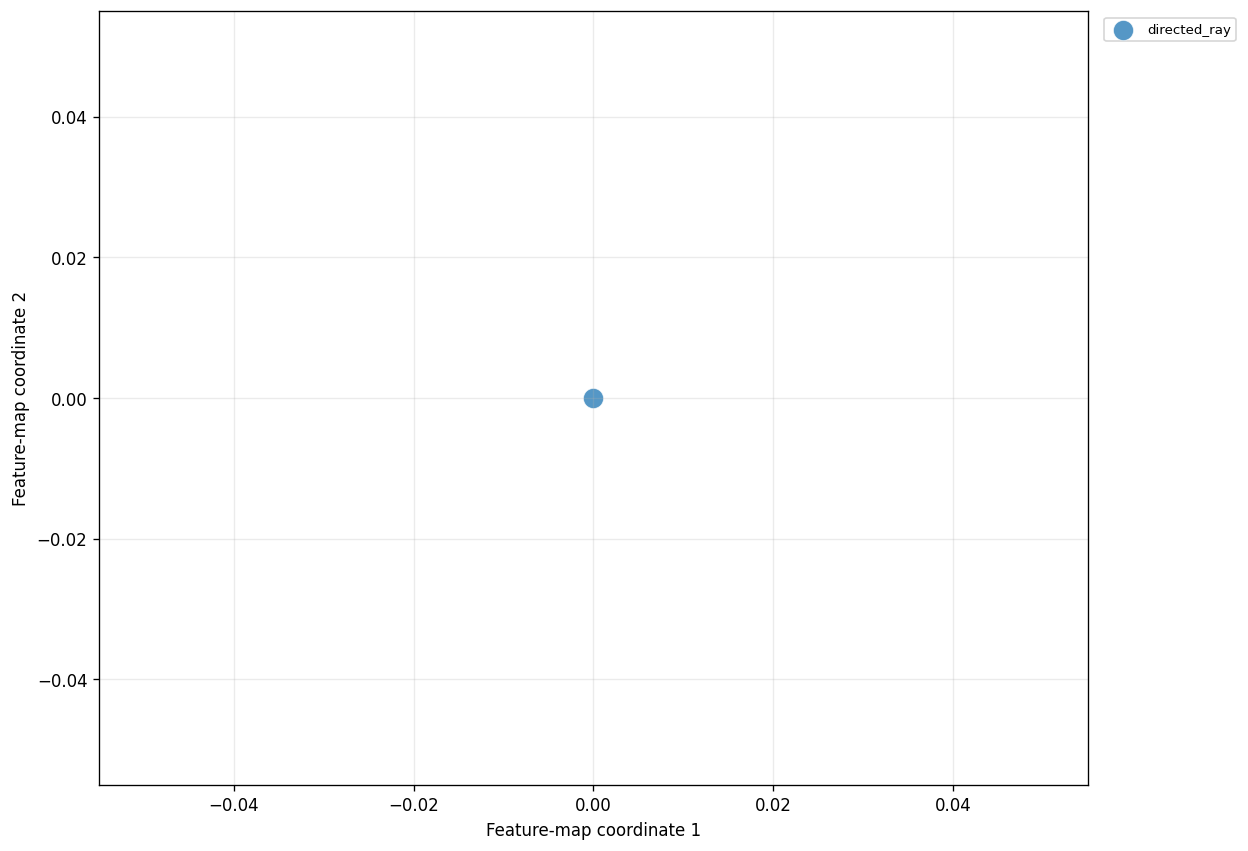

### Live unit-sphere surface

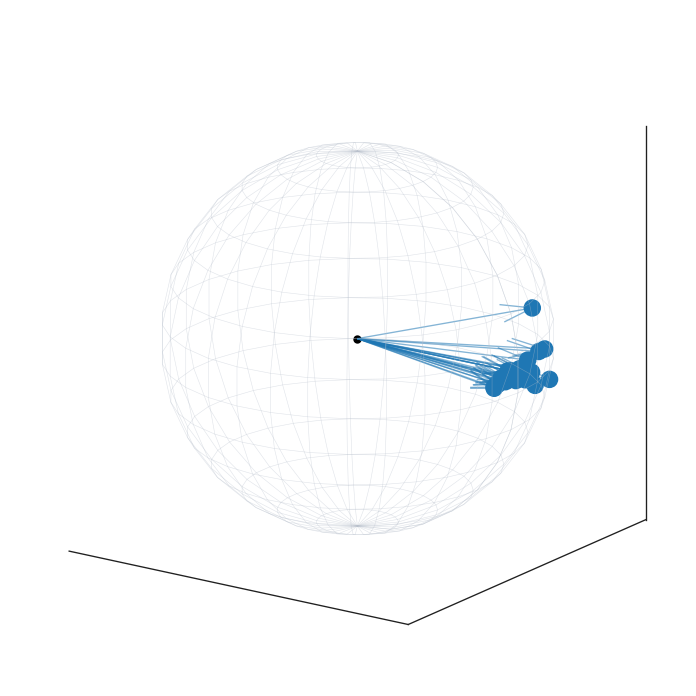

### Live two-dimensional projection

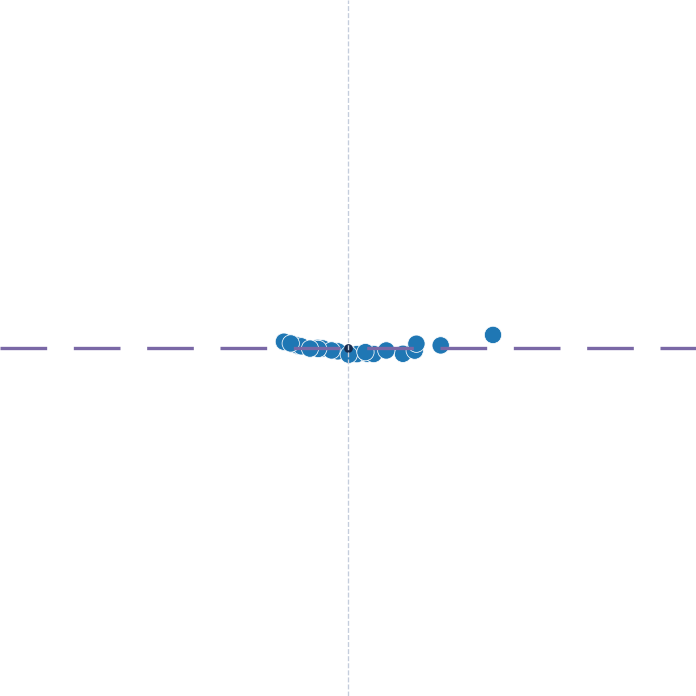

In [5]:
live_files = results[keys.FEGA_VISUALIZATION].files
for figure_name, heading in (
    ("geometry_atlas.png", "Live geometry atlas"),
    ("sphere_surface.png", "Live unit-sphere surface"),
    ("projection_2d.png", "Live two-dimensional projection"),
):
    figure_path = next(path for path in live_files if path.name == figure_name)
    display(Markdown(f"### {heading}"))
    display(Image(filename=str(figure_path)))

## 5. Compact source-derived geometry comparison

The compact bundle contains per-feature effect-space kernels, derived coordinates, labels, metrics, and reference PNGs for one representative of each reported family. Murano freshly renders an atlas, sphere-surface view, and family-specific projection from those arrays below. Each copied source PNG is shown beside its Murano rerender as a labeled visual target.

The primary standard-SAE run supplies seven families; the multi-mode example is a separately labeled Matryoshka supplement. This comparison starts after source geometry export. It excludes prompts, model and SAE weights, full residual-space effect and Gram artifacts, and vocabulary coordinates; it cannot rerun prompt preparation, effect collection, vMF fitting, paper datasets, feature selection, or aggregate analyses.

### Geometry atlas — Murano rerender

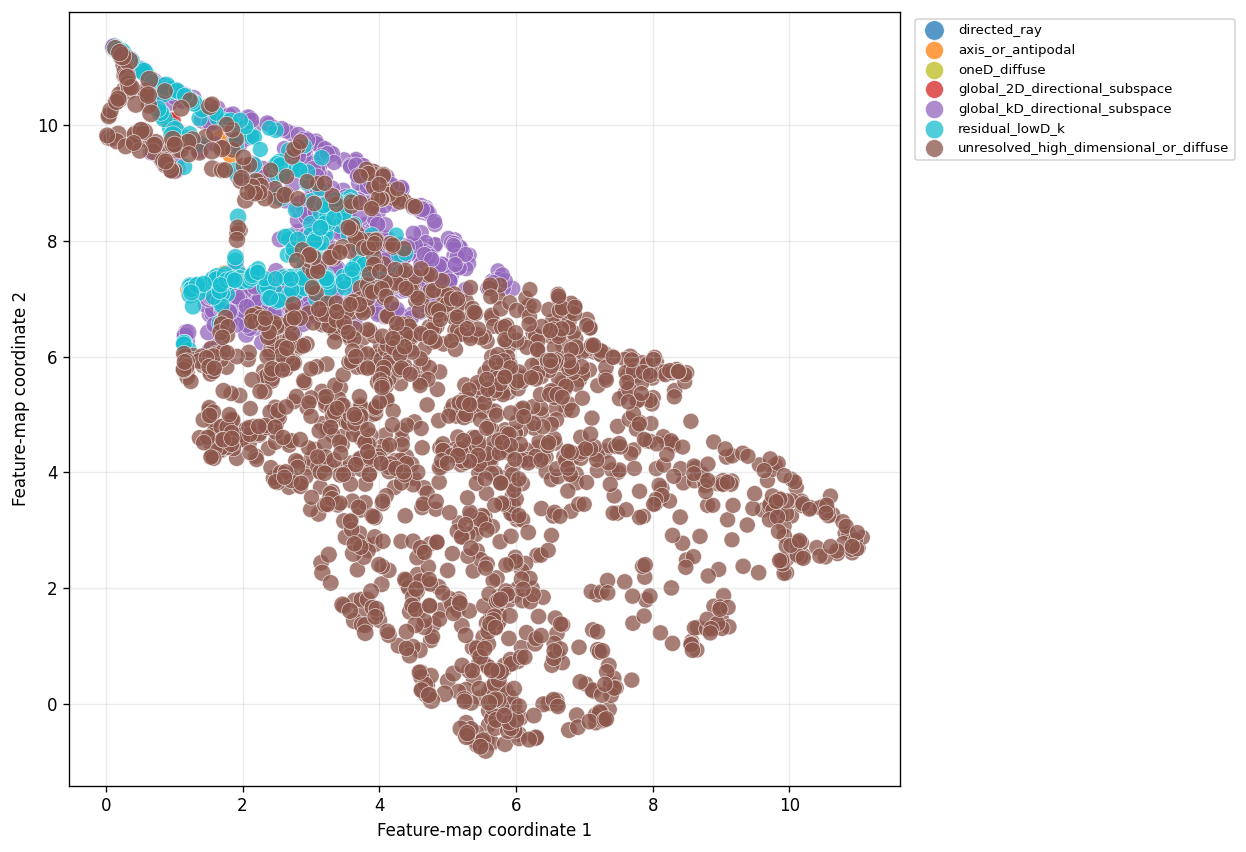

**Source reference**

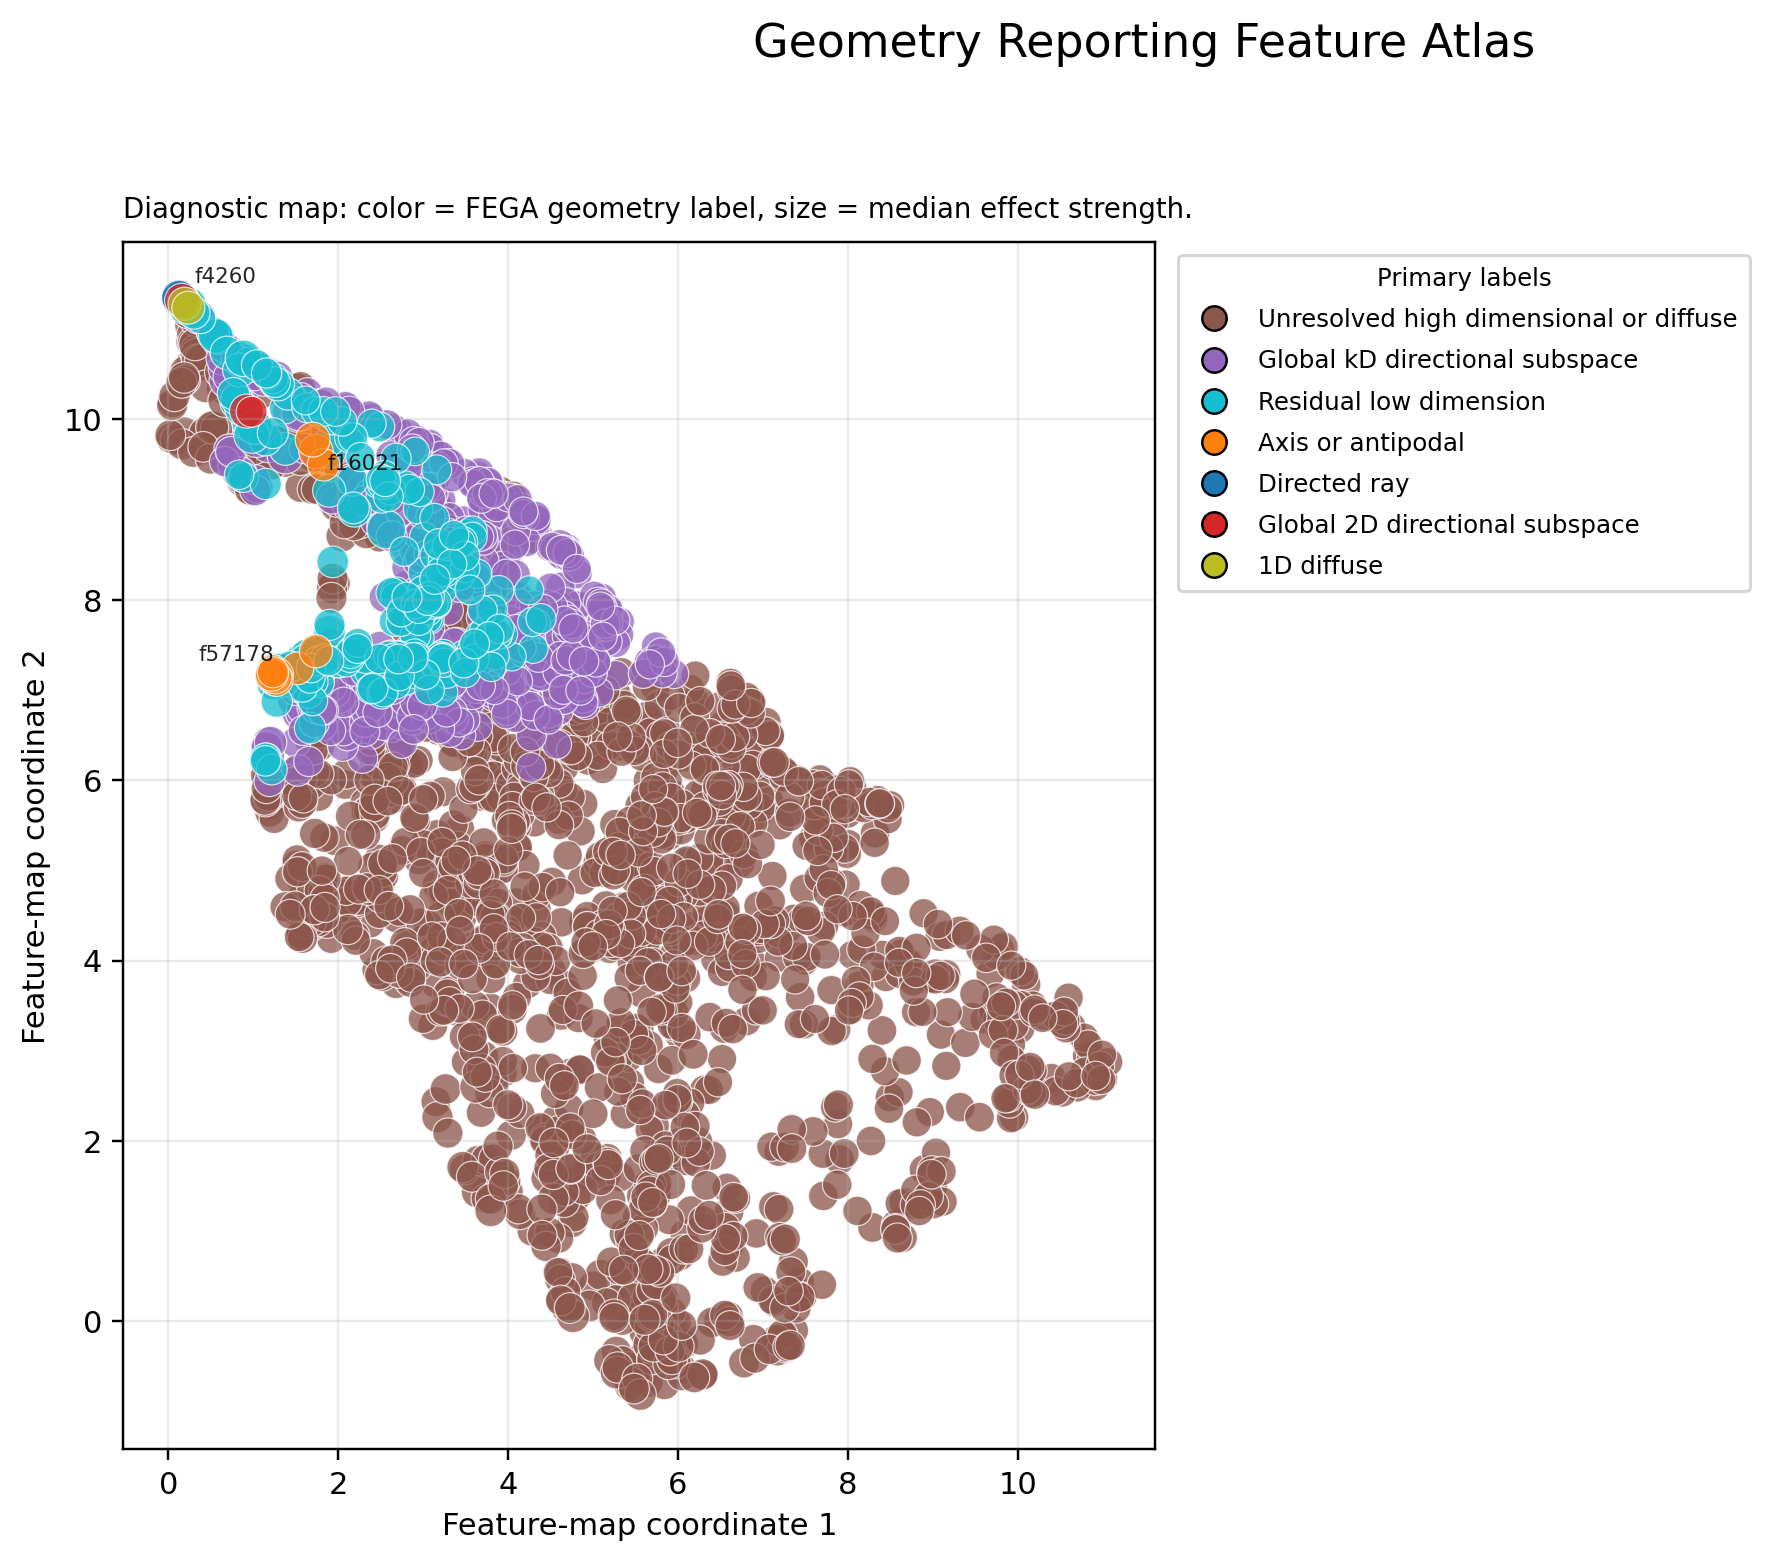

### axis_or_antipodal — feature 14513

Retained contexts: 19 · median effect magnitude: 90.02

**Murano rerender — sphere surface**

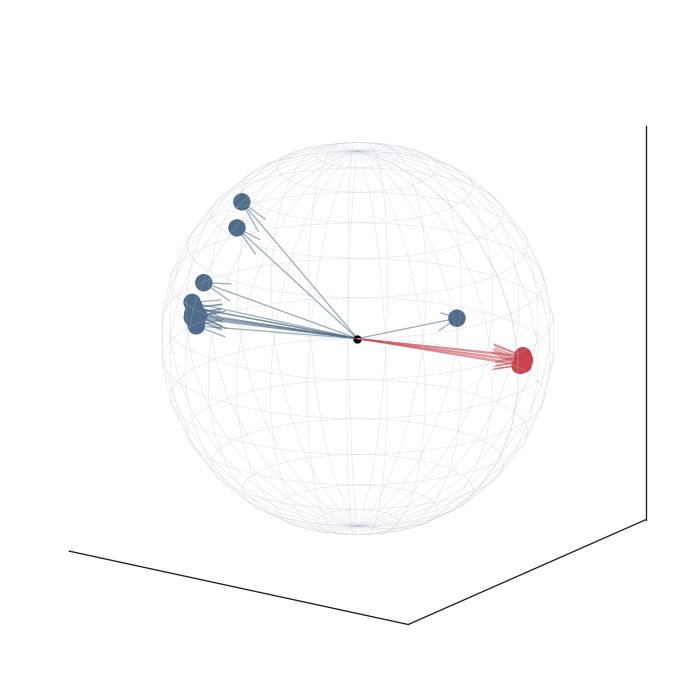

**Source reference — sphere surface**

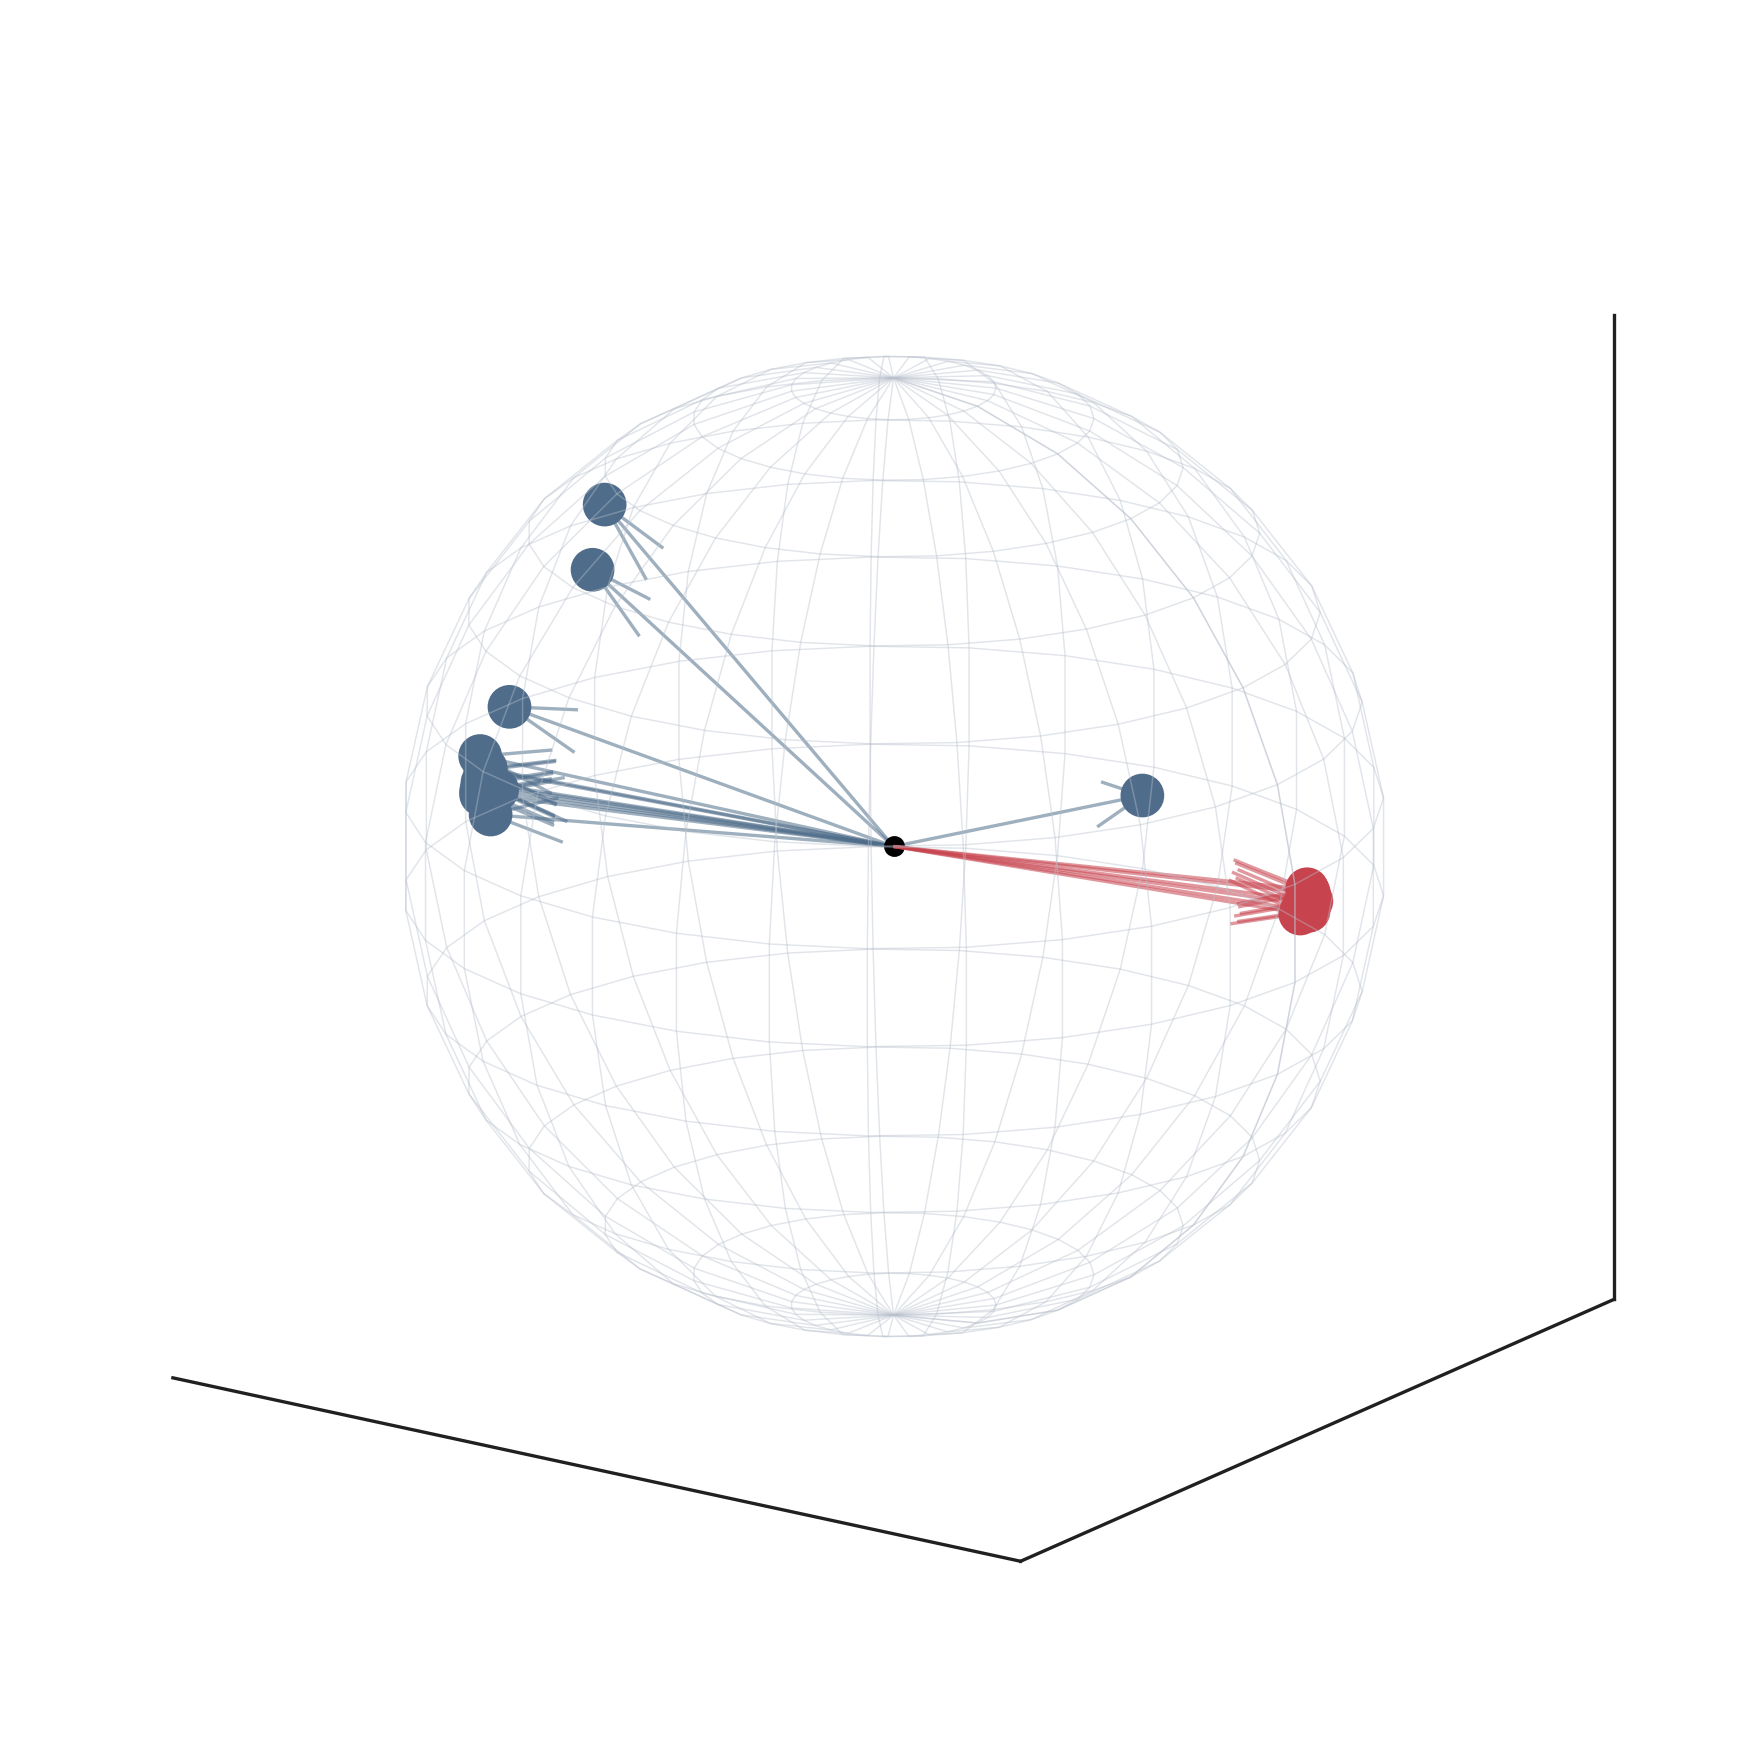

**Murano rerender — family projection**

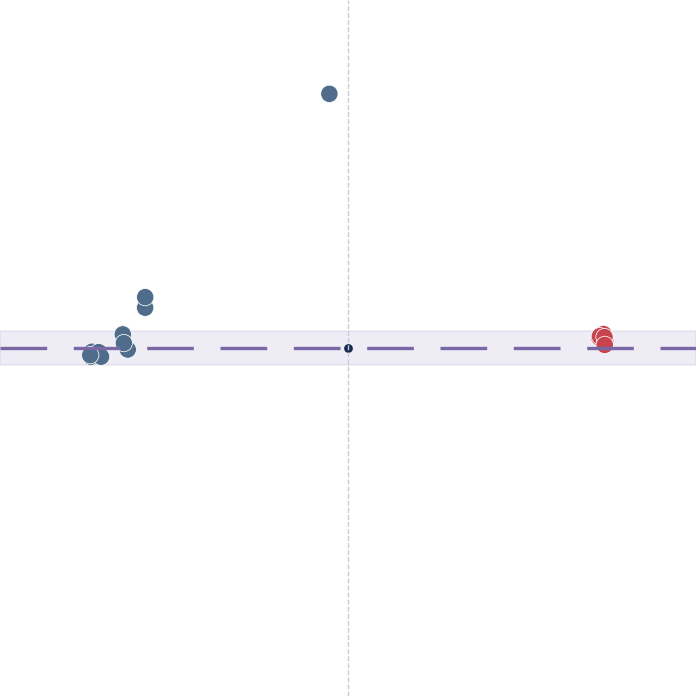

**Source reference — family projection**

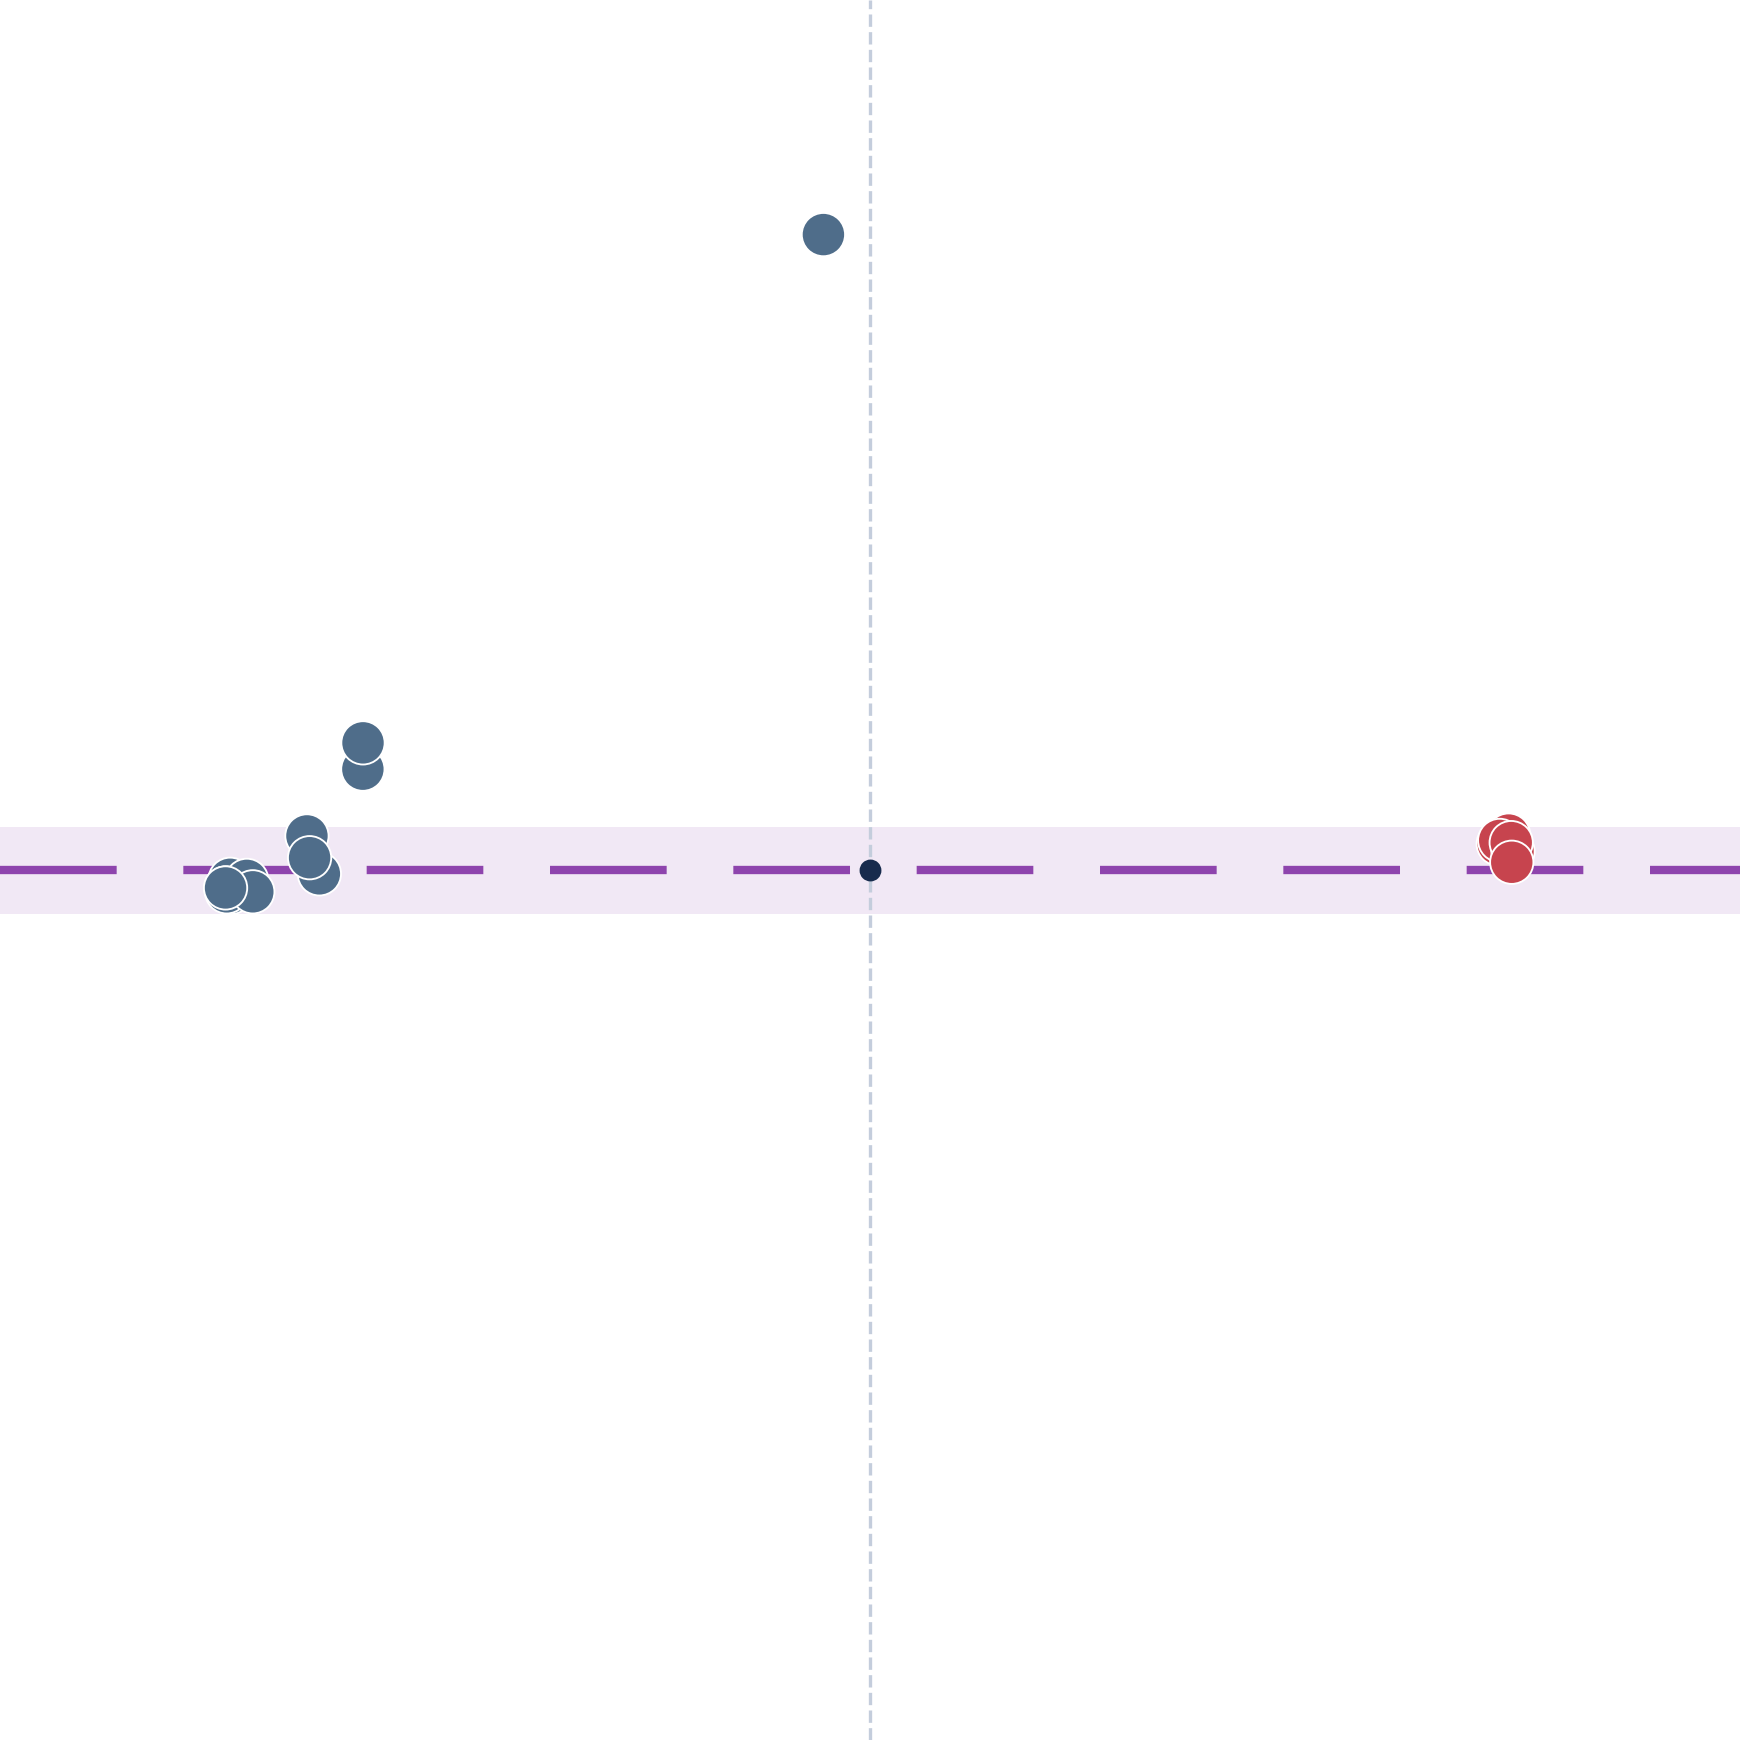

### directed_ray — feature 33760

Retained contexts: 64 · median effect magnitude: 254.1

**Murano rerender — sphere surface**

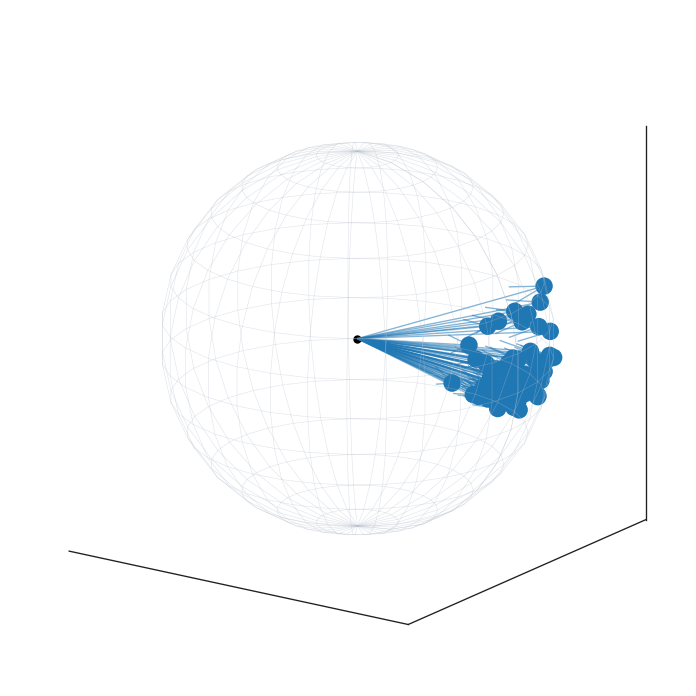

**Source reference — sphere surface**

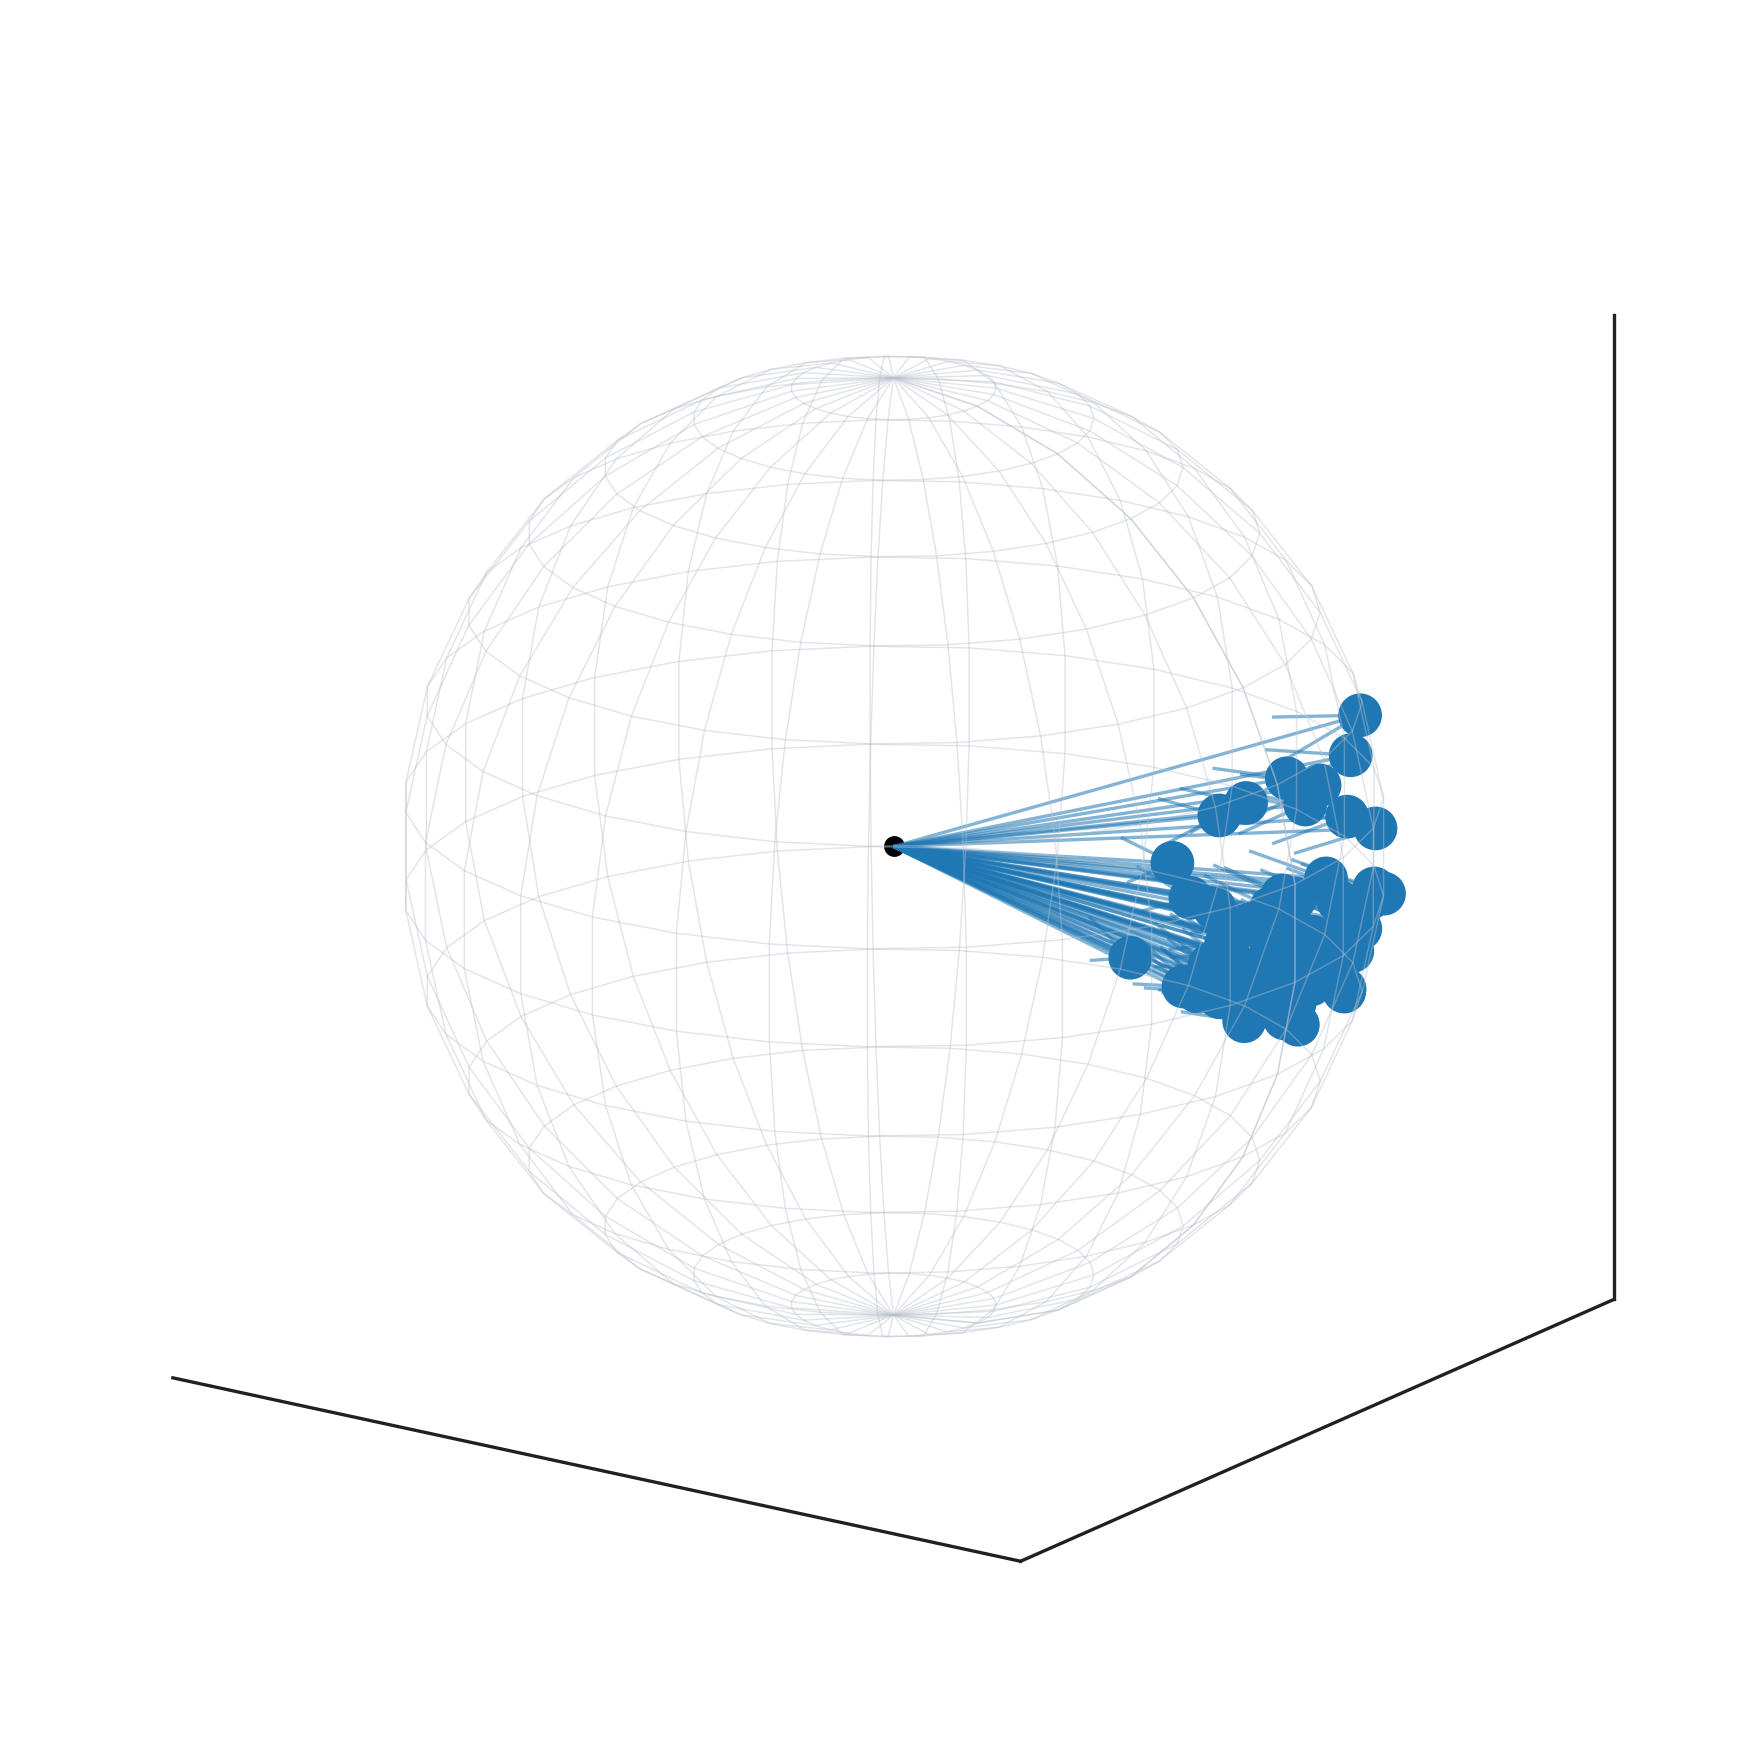

**Murano rerender — family projection**

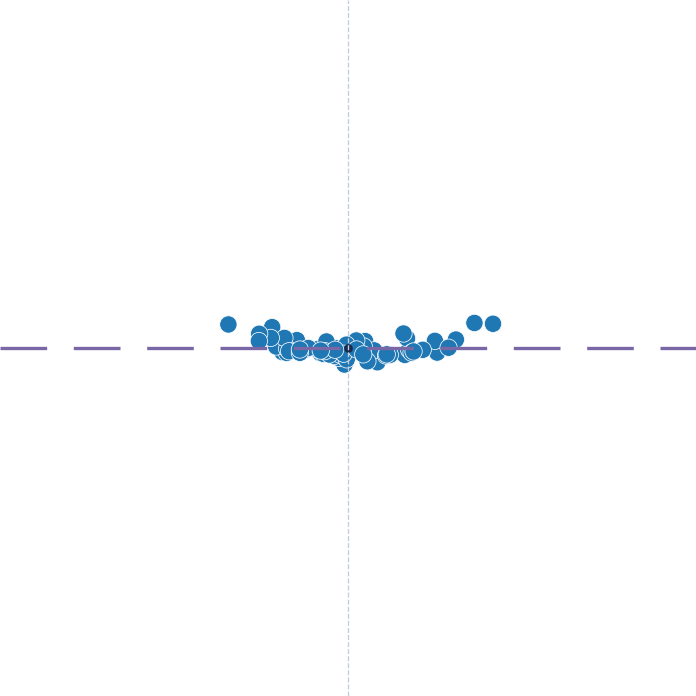

**Source reference — family projection**

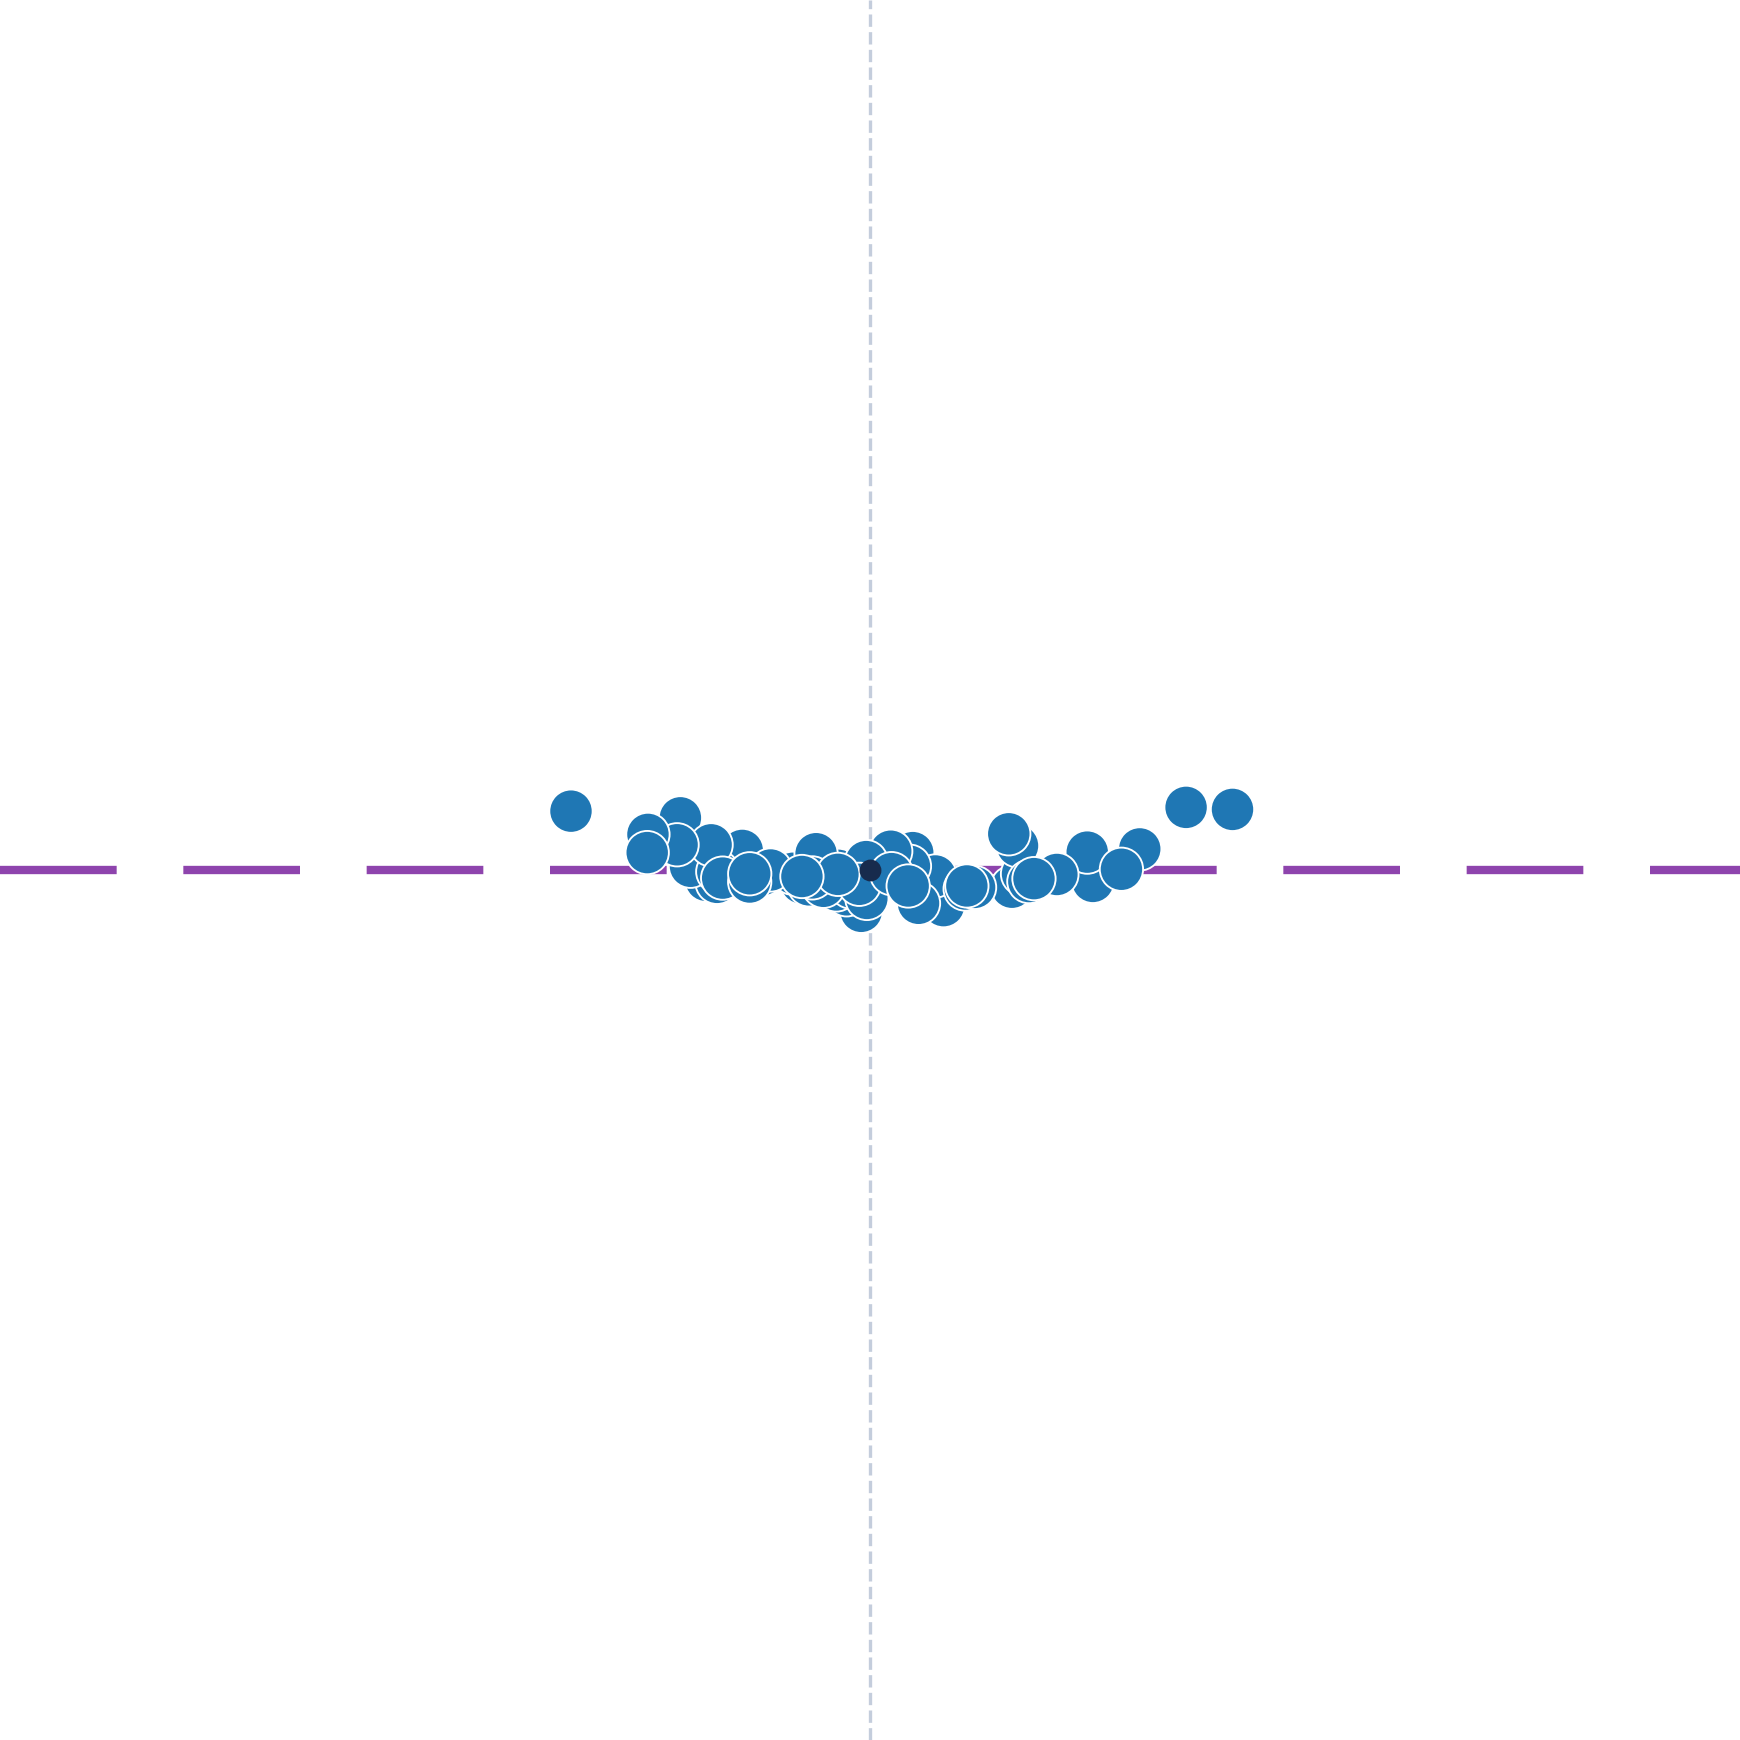

### global_2D_directional_subspace — feature 54361

Retained contexts: 13 · median effect magnitude: 157.5

**Murano rerender — sphere surface**

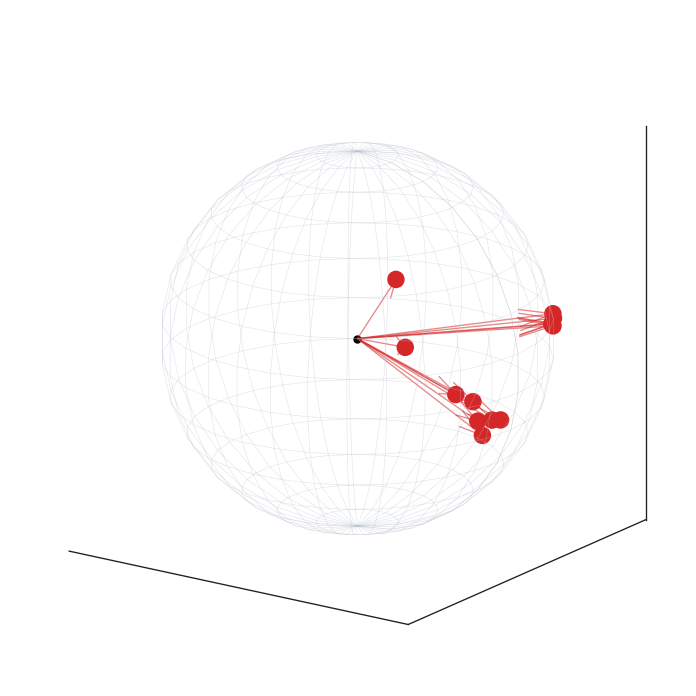

**Source reference — sphere surface**

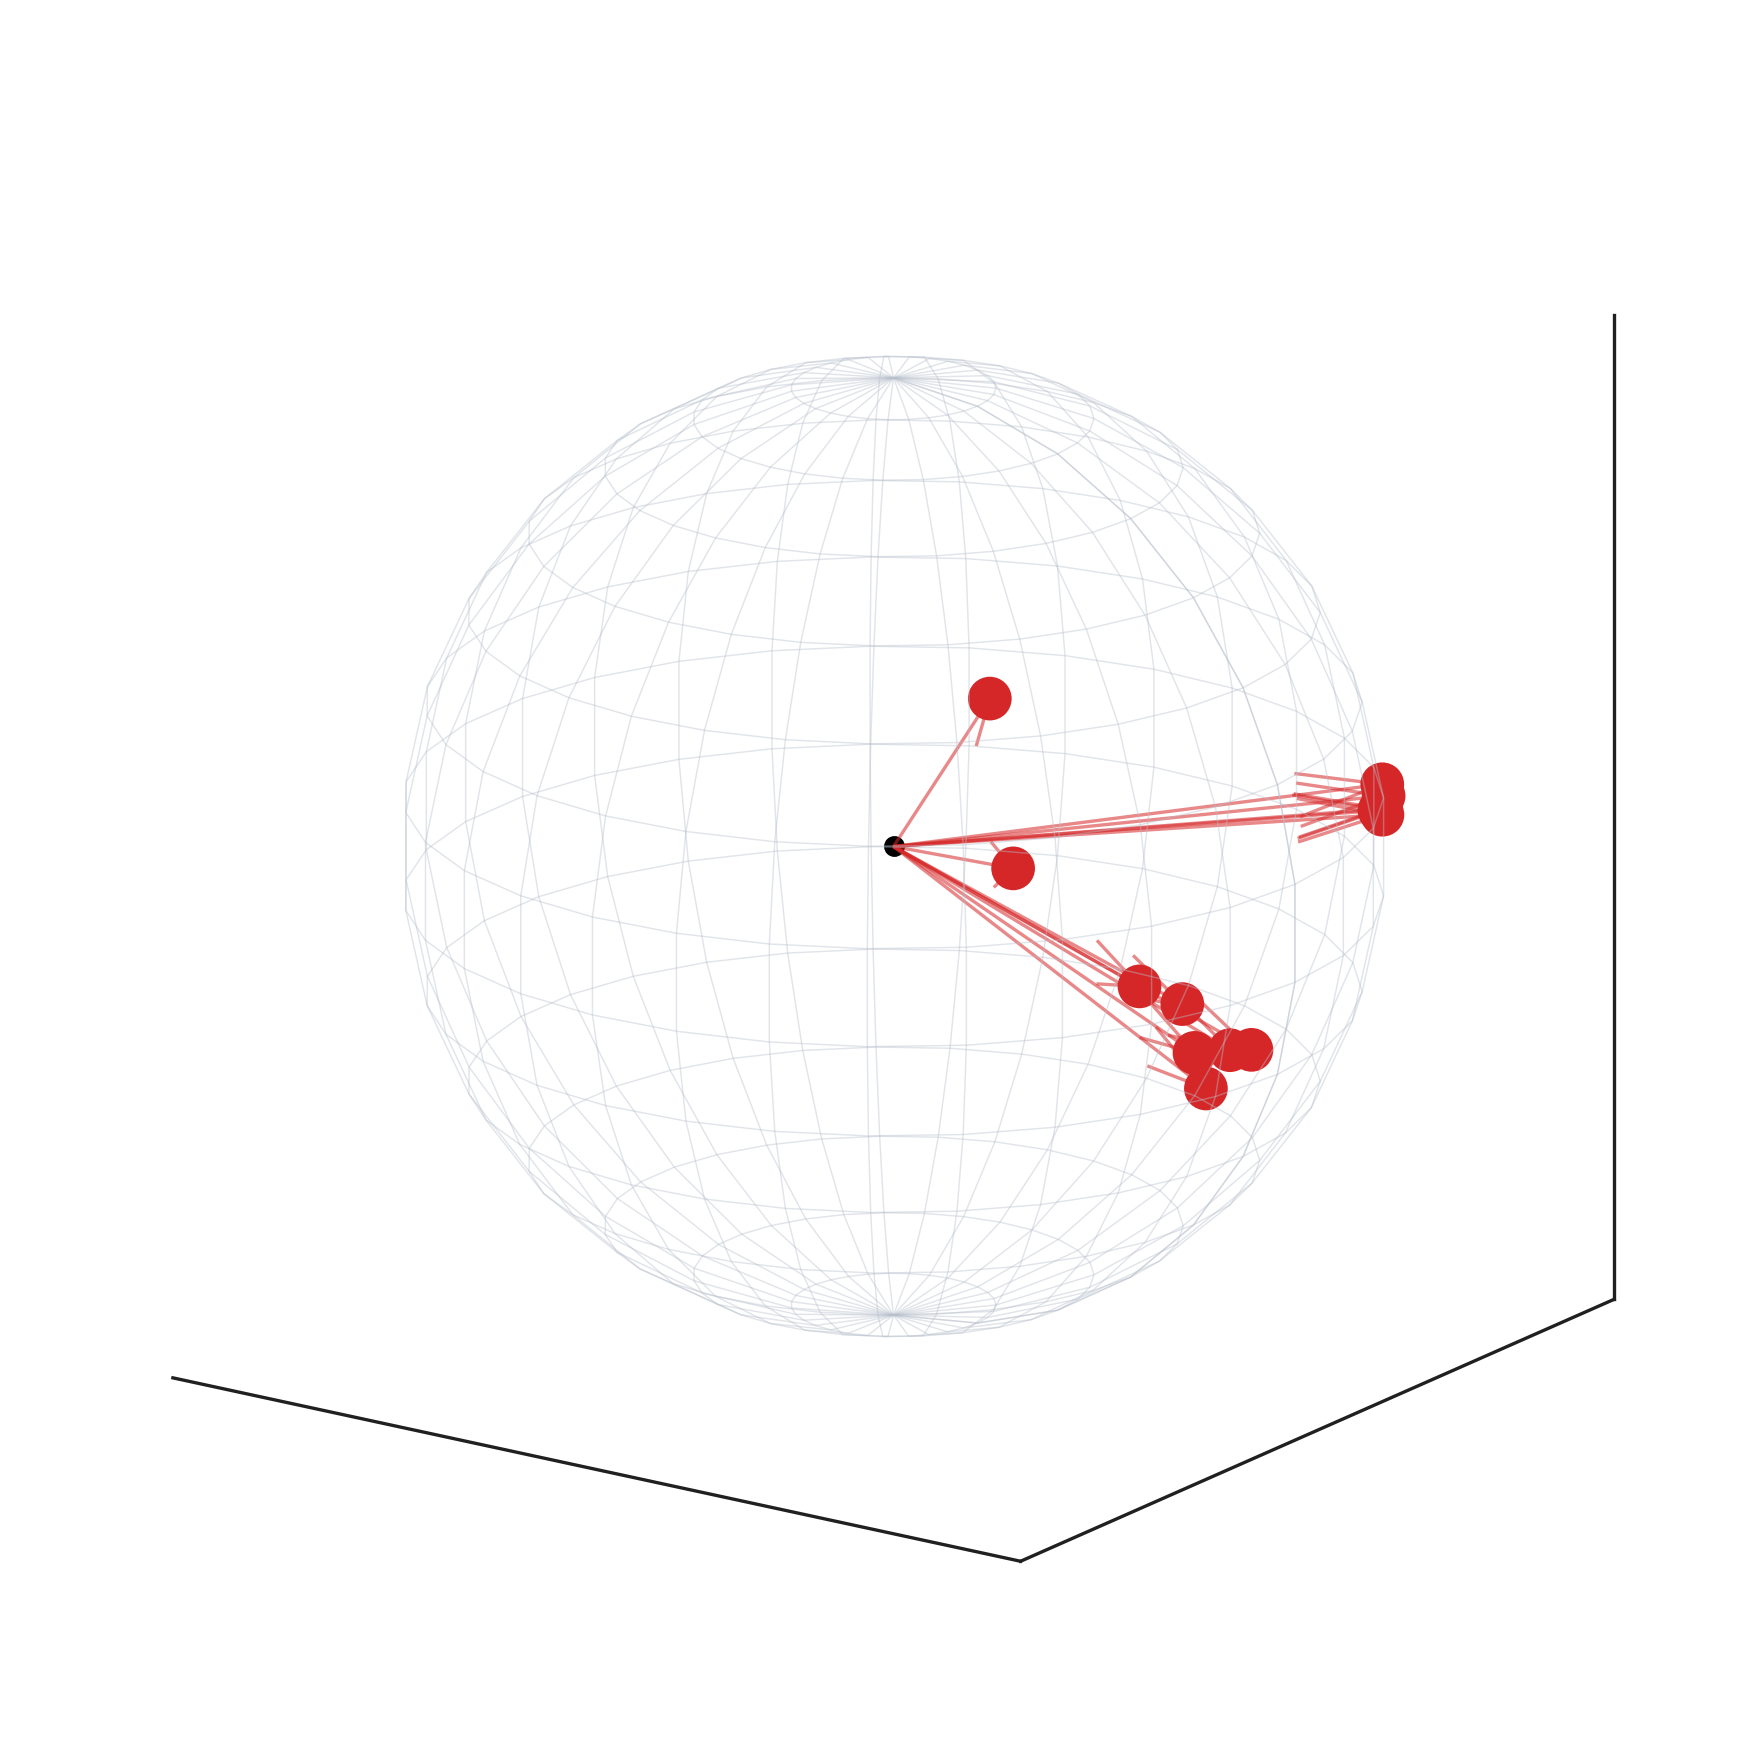

**Murano rerender — family projection**

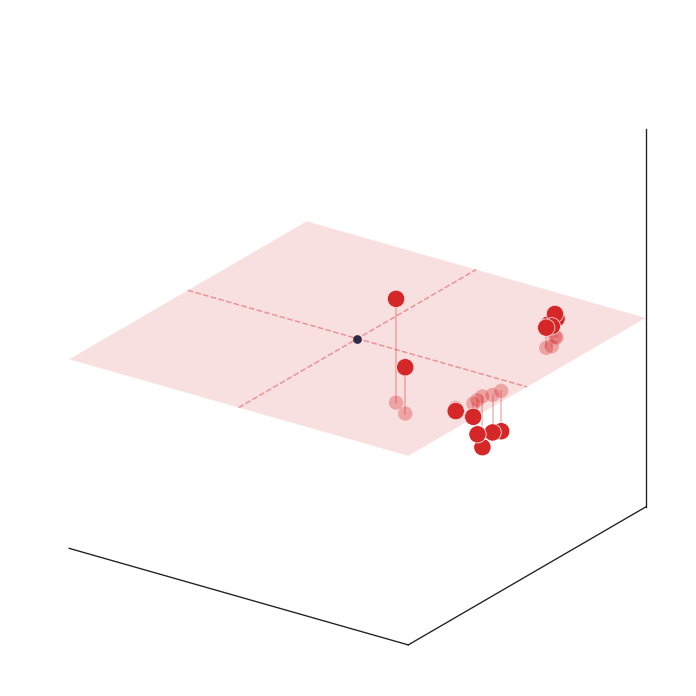

**Source reference — family projection**

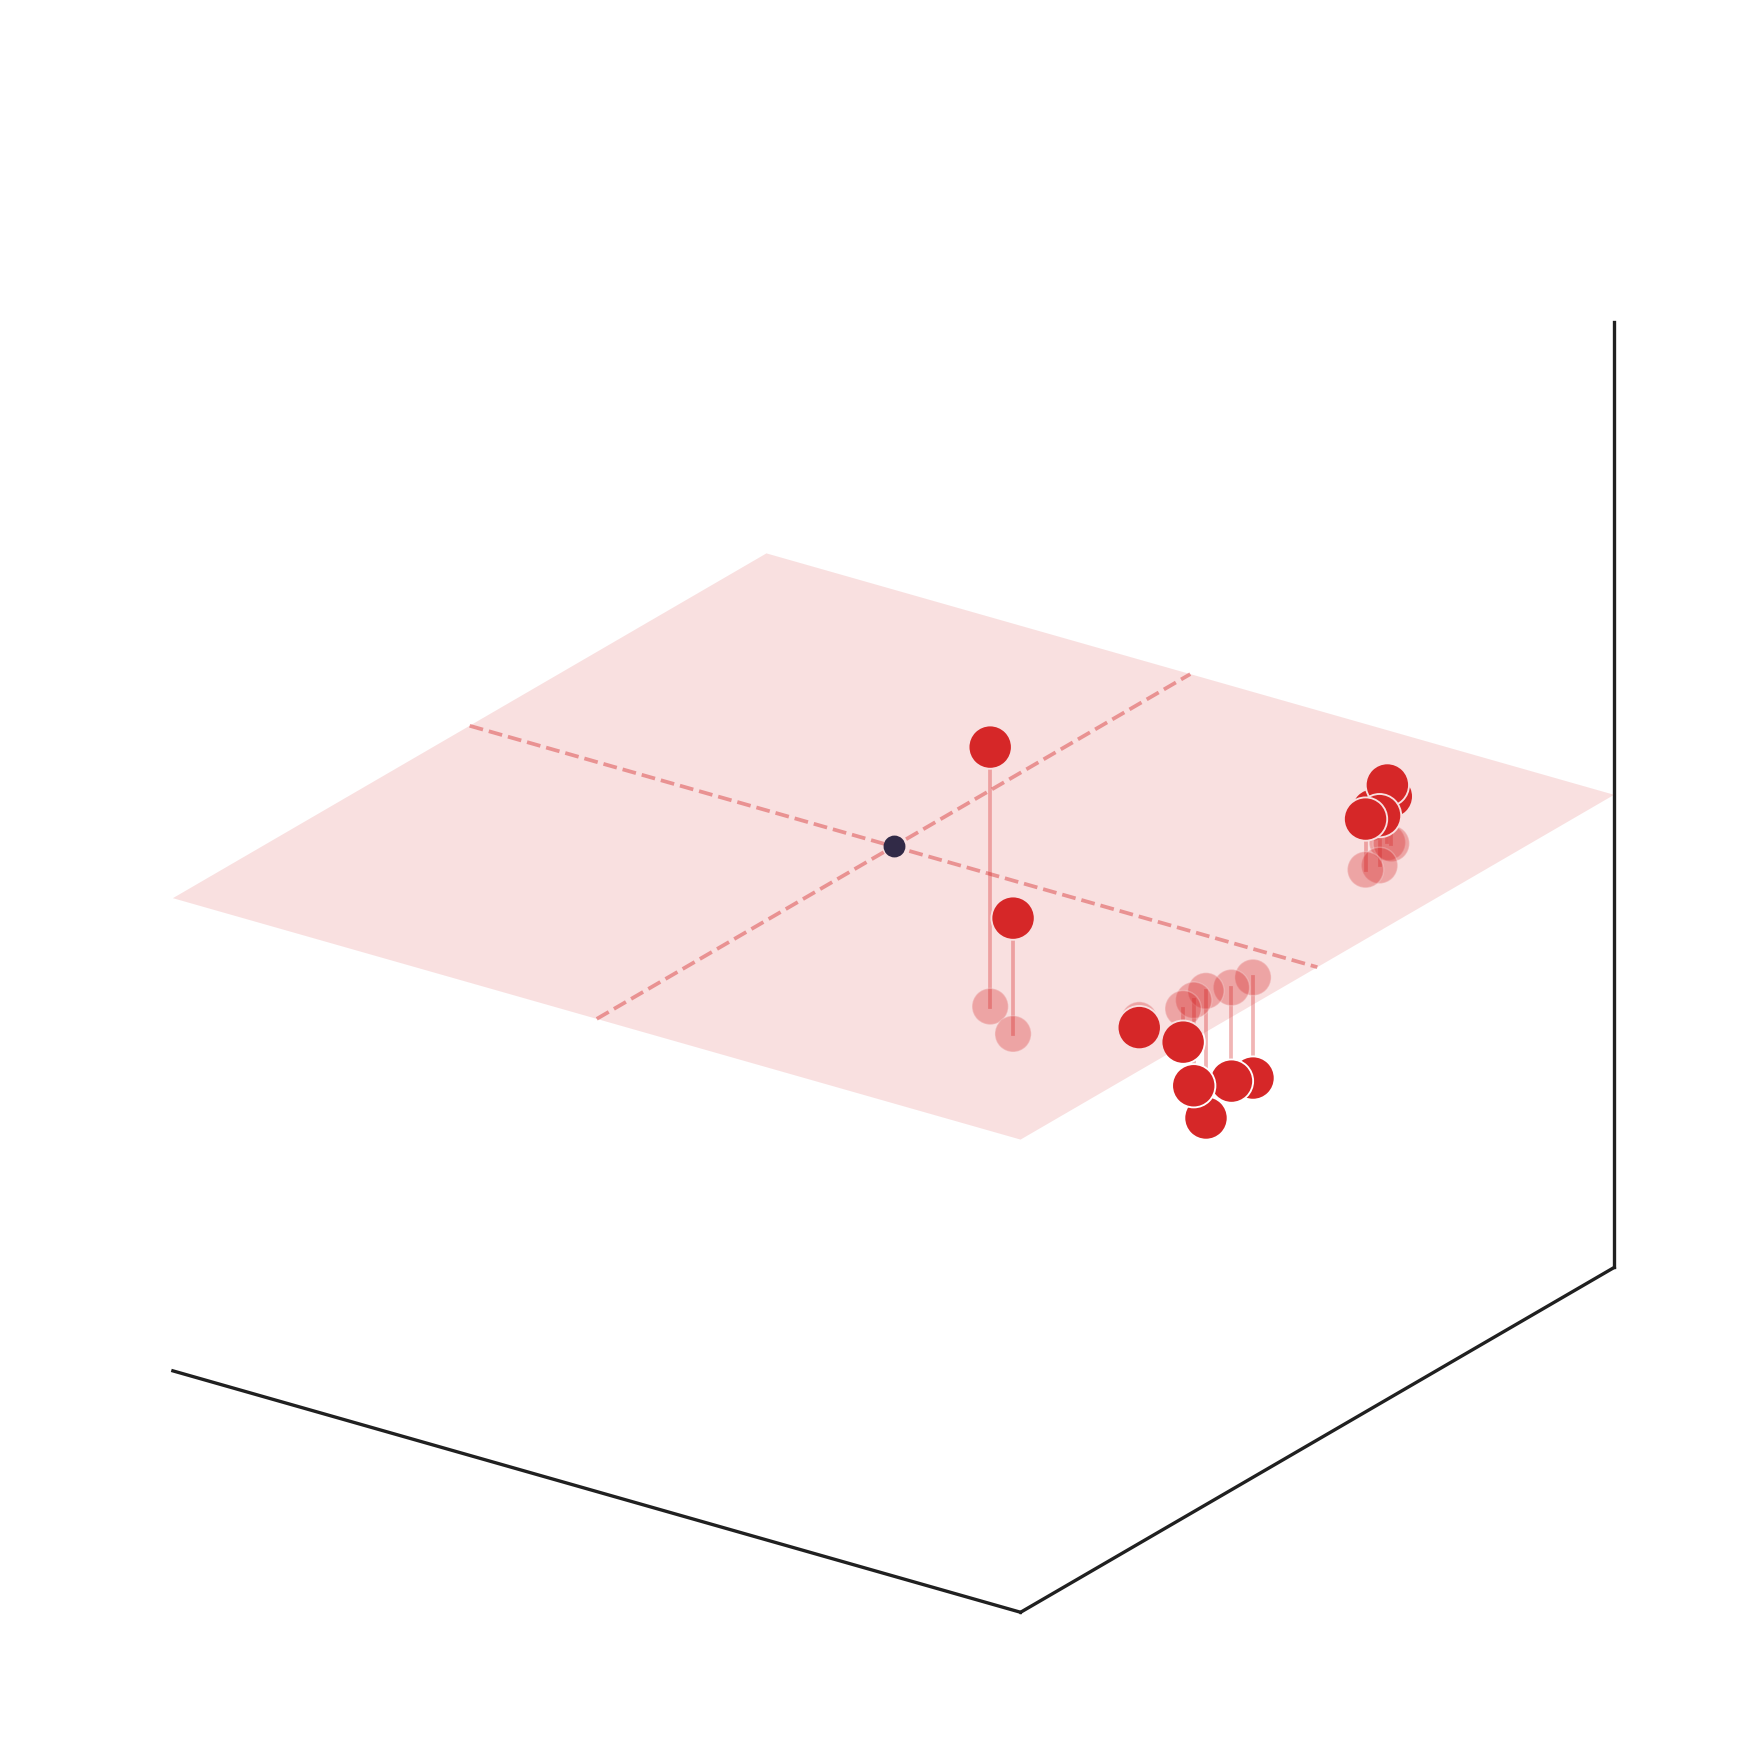

### global_kD_directional_subspace — feature 32542

Retained contexts: 64 · median effect magnitude: 85.54

**Murano rerender — sphere surface**

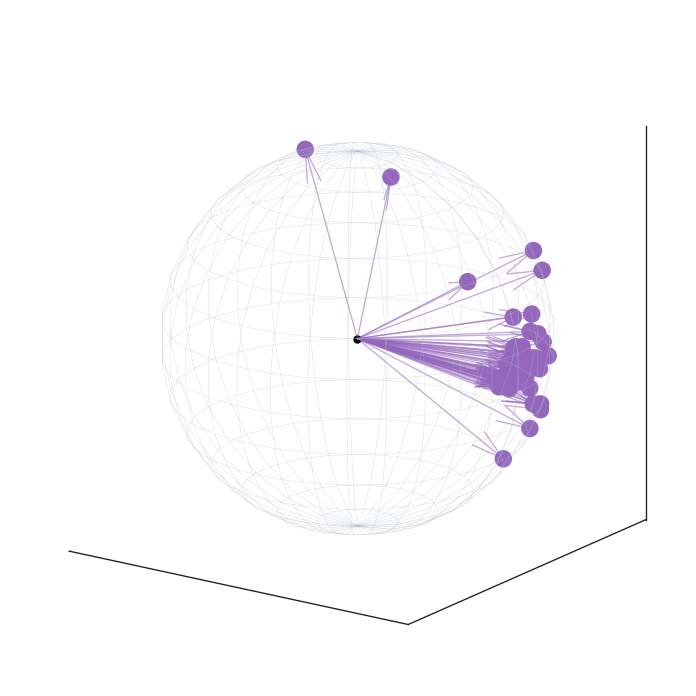

**Source reference — sphere surface**

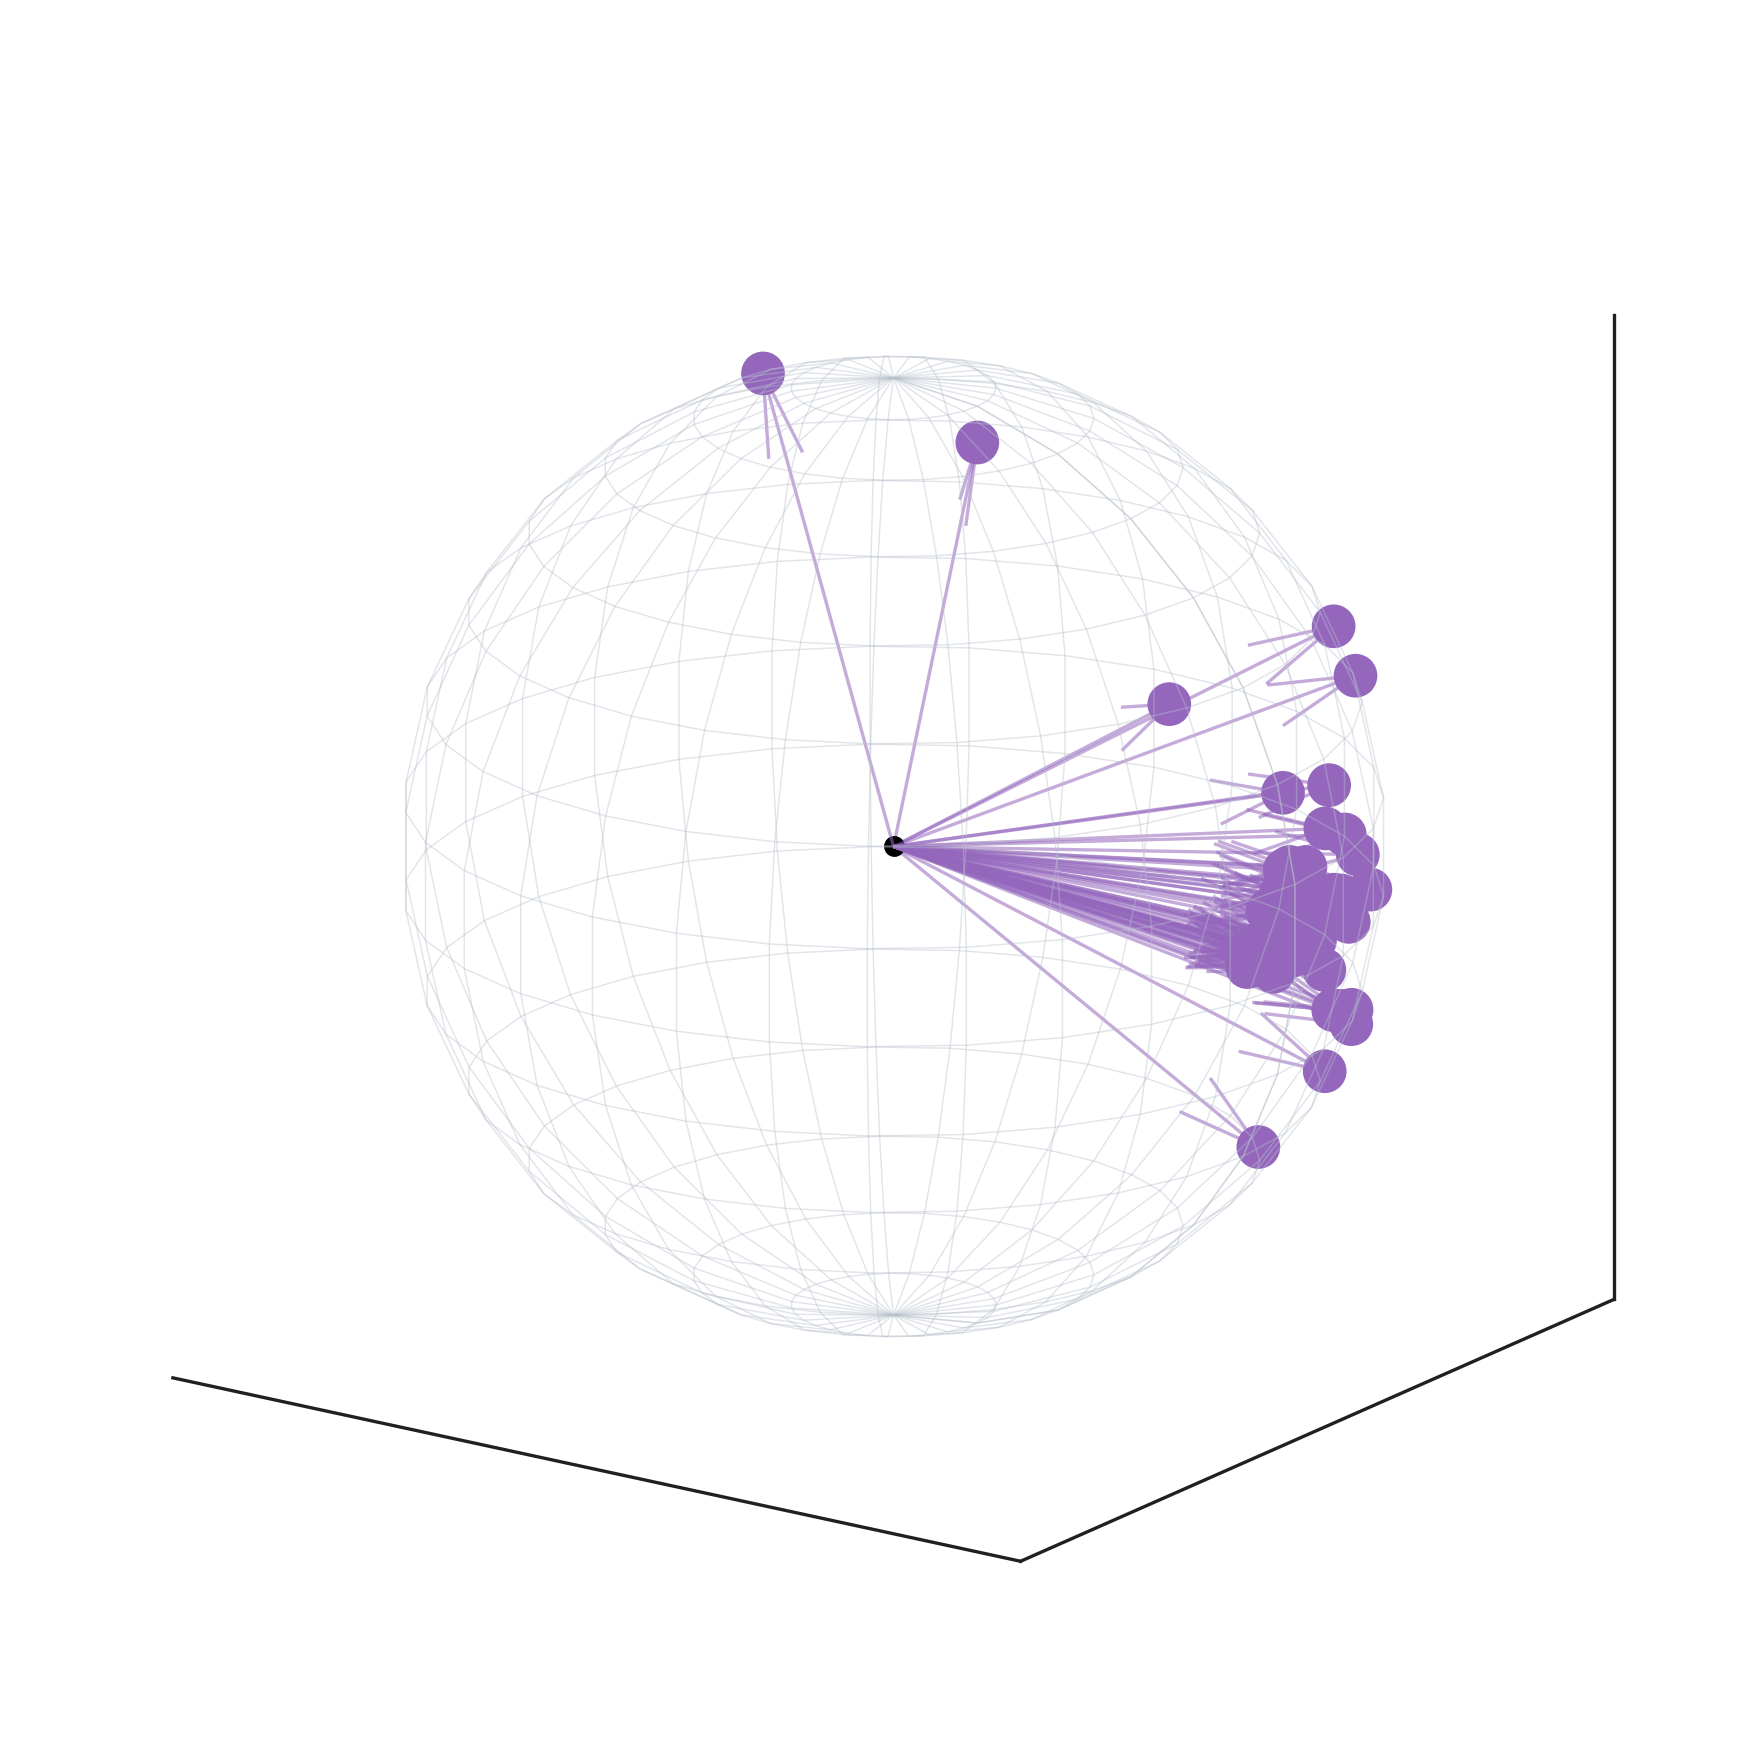

**Murano rerender — family projection**

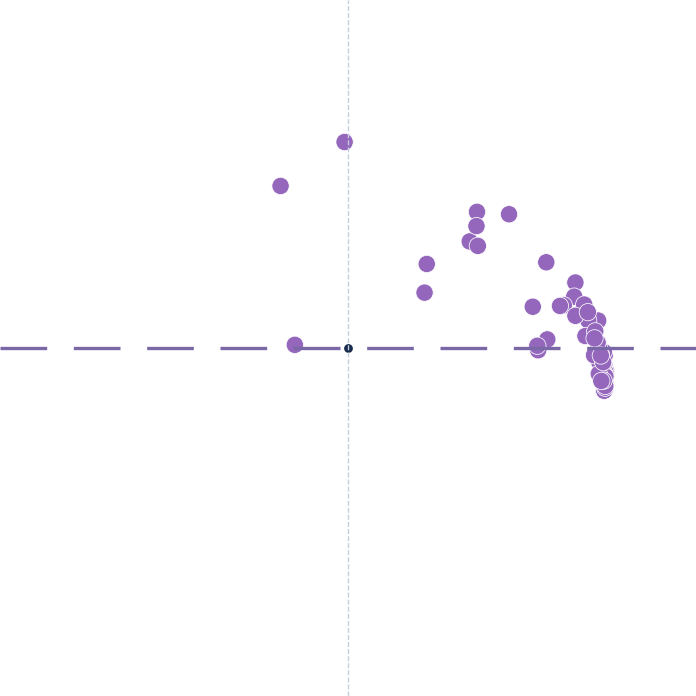

**Source reference — family projection**

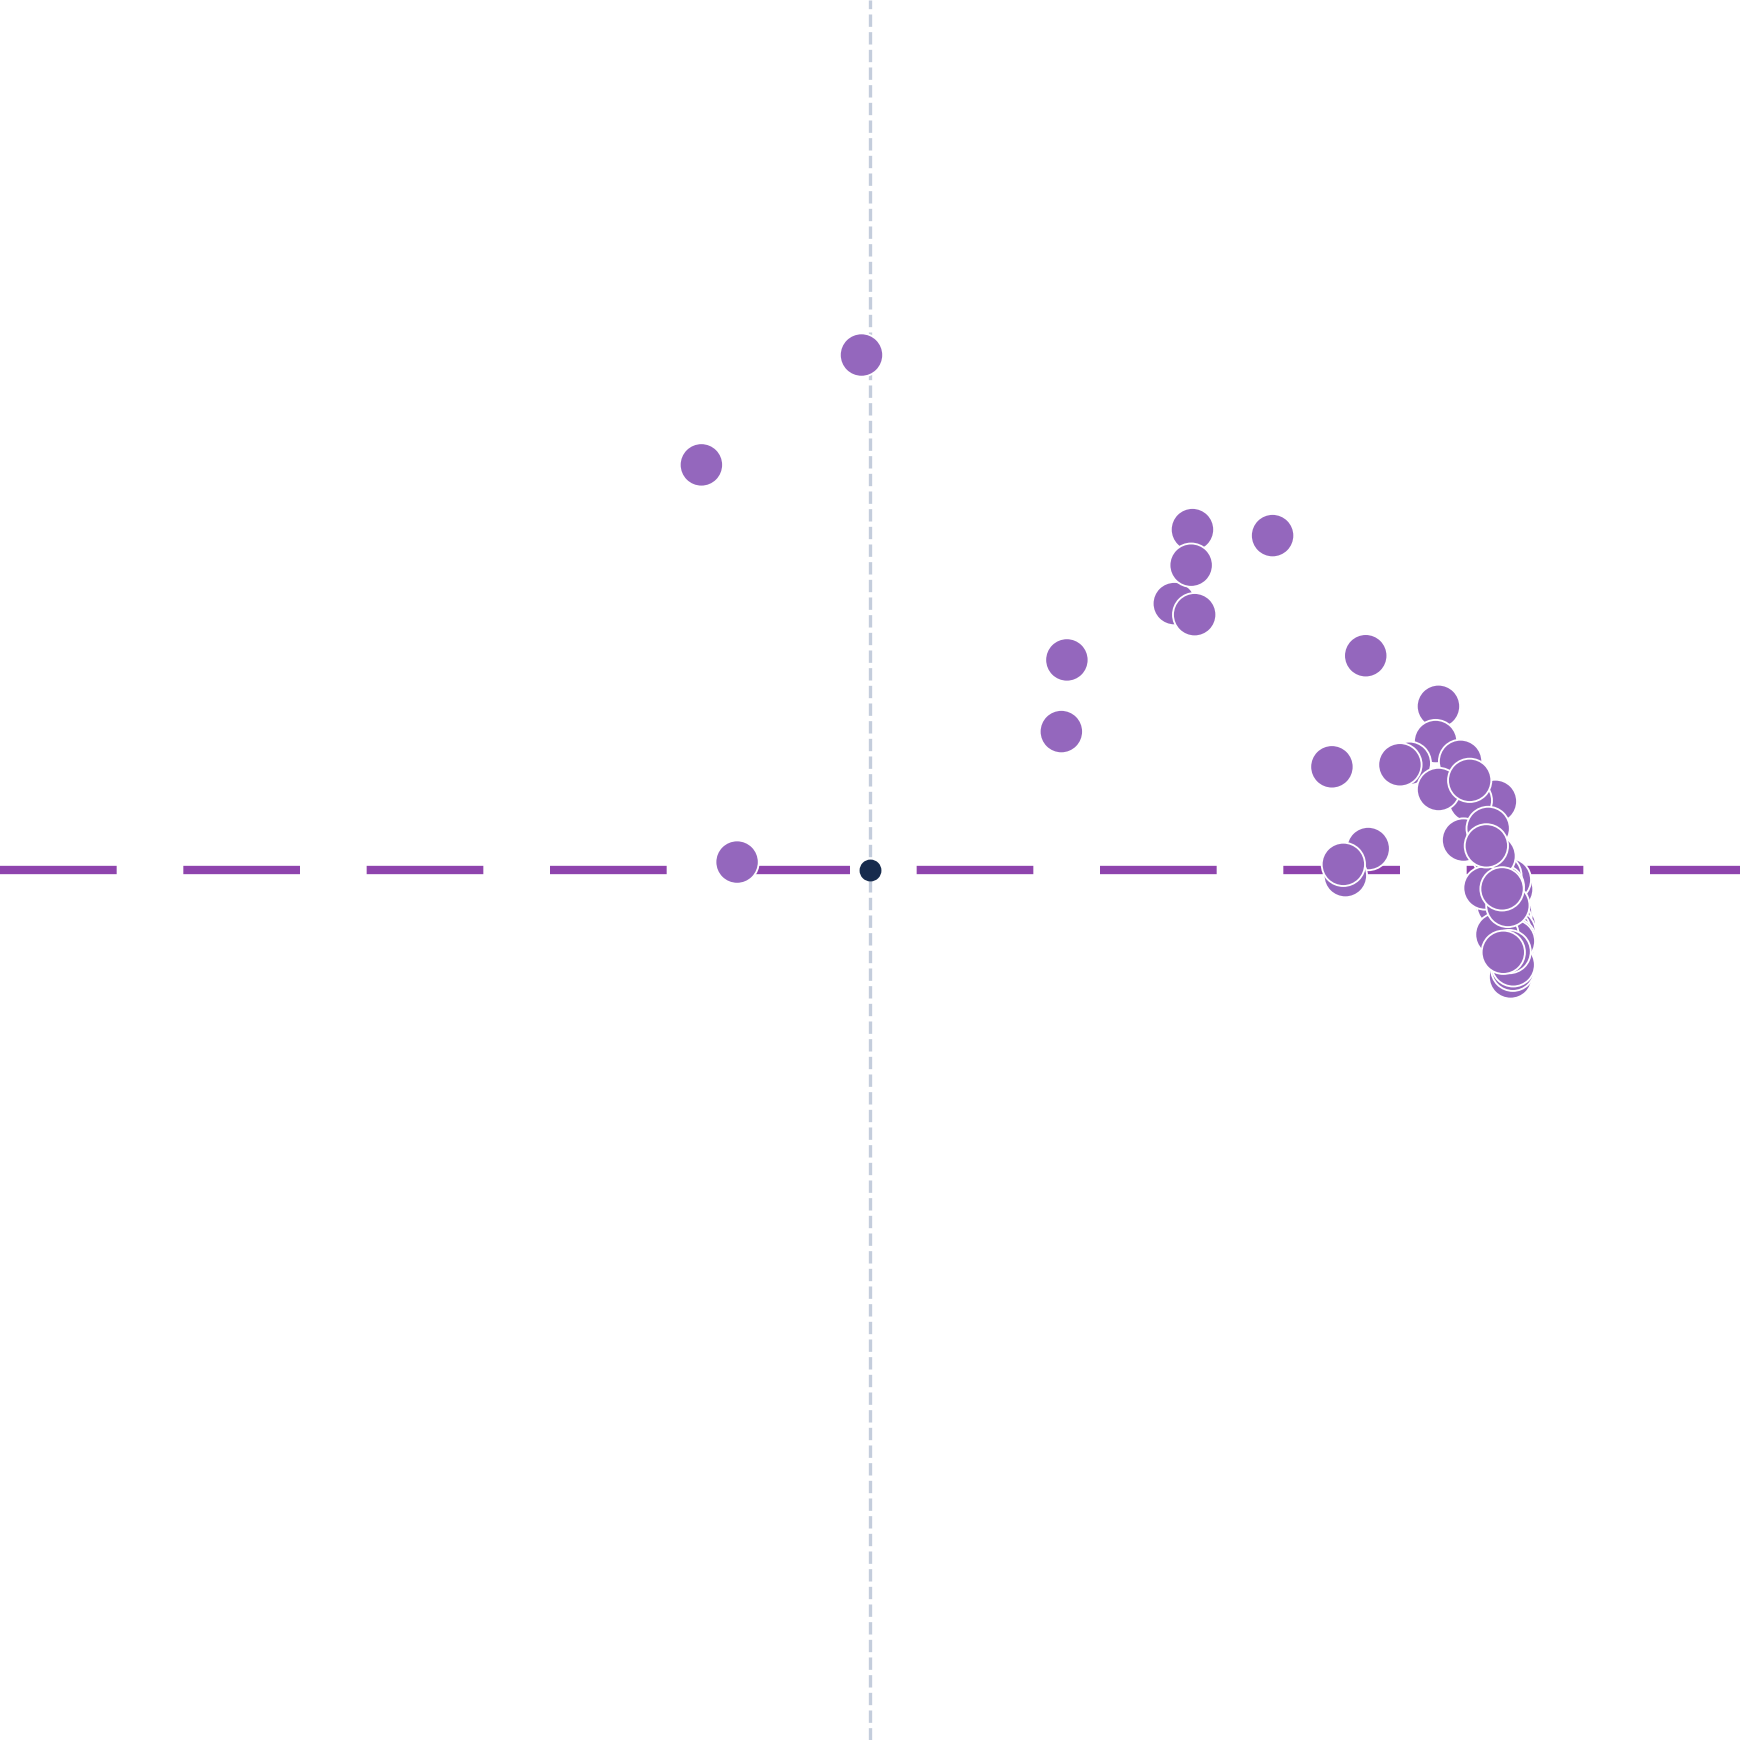

### multi_mode_directional_geometry — feature 1425 — Matryoshka supplement

Retained contexts: 9 · median effect magnitude: 101.3

**Murano rerender — sphere surface**

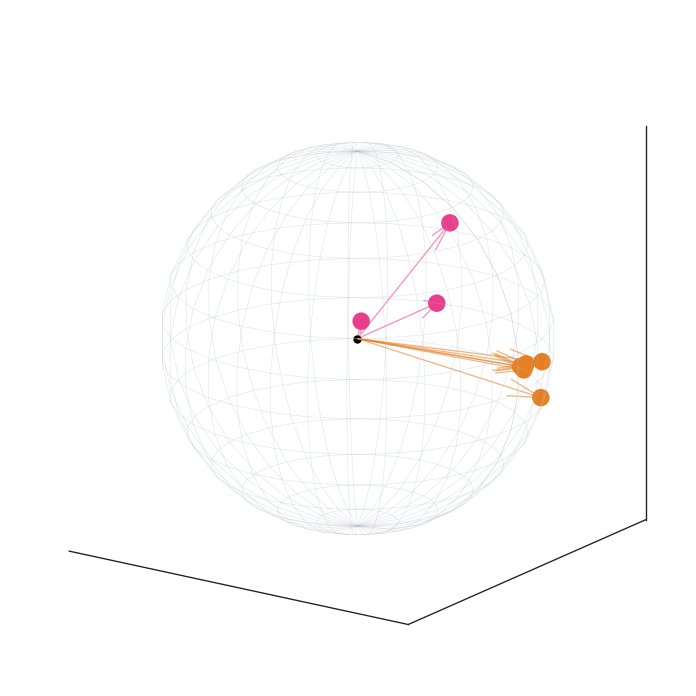

**Source reference — sphere surface**

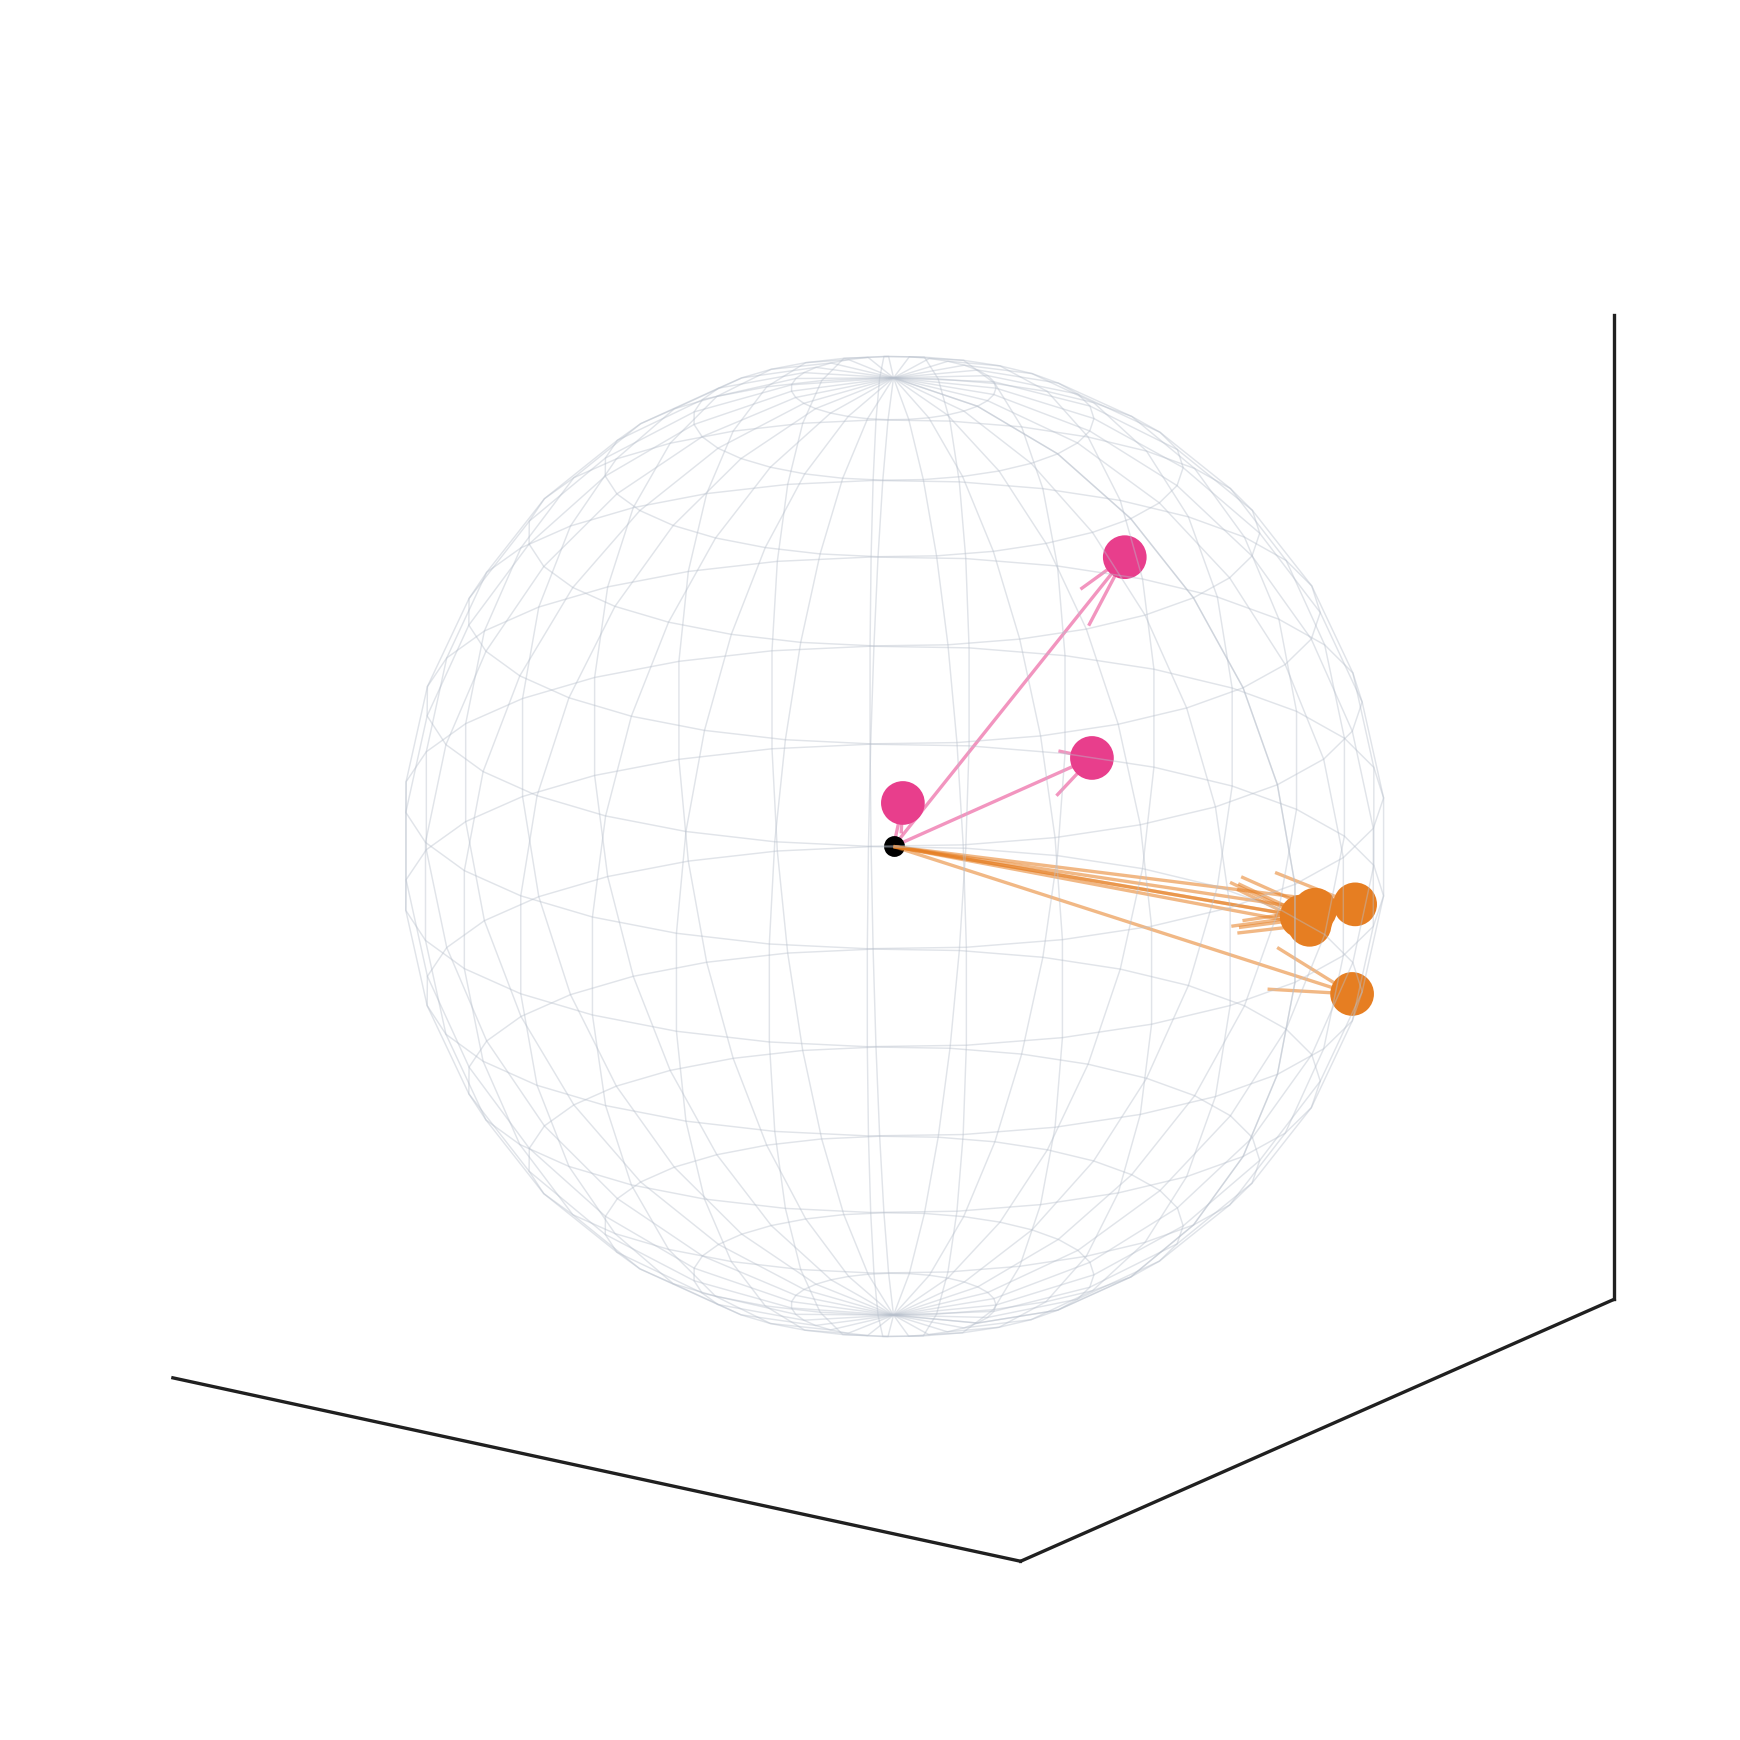

**Murano rerender — family projection**

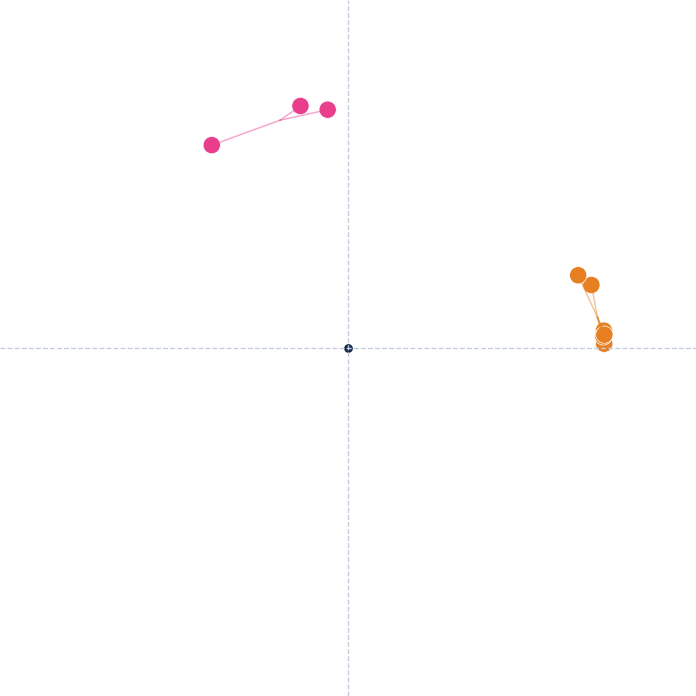

**Source reference — family projection**

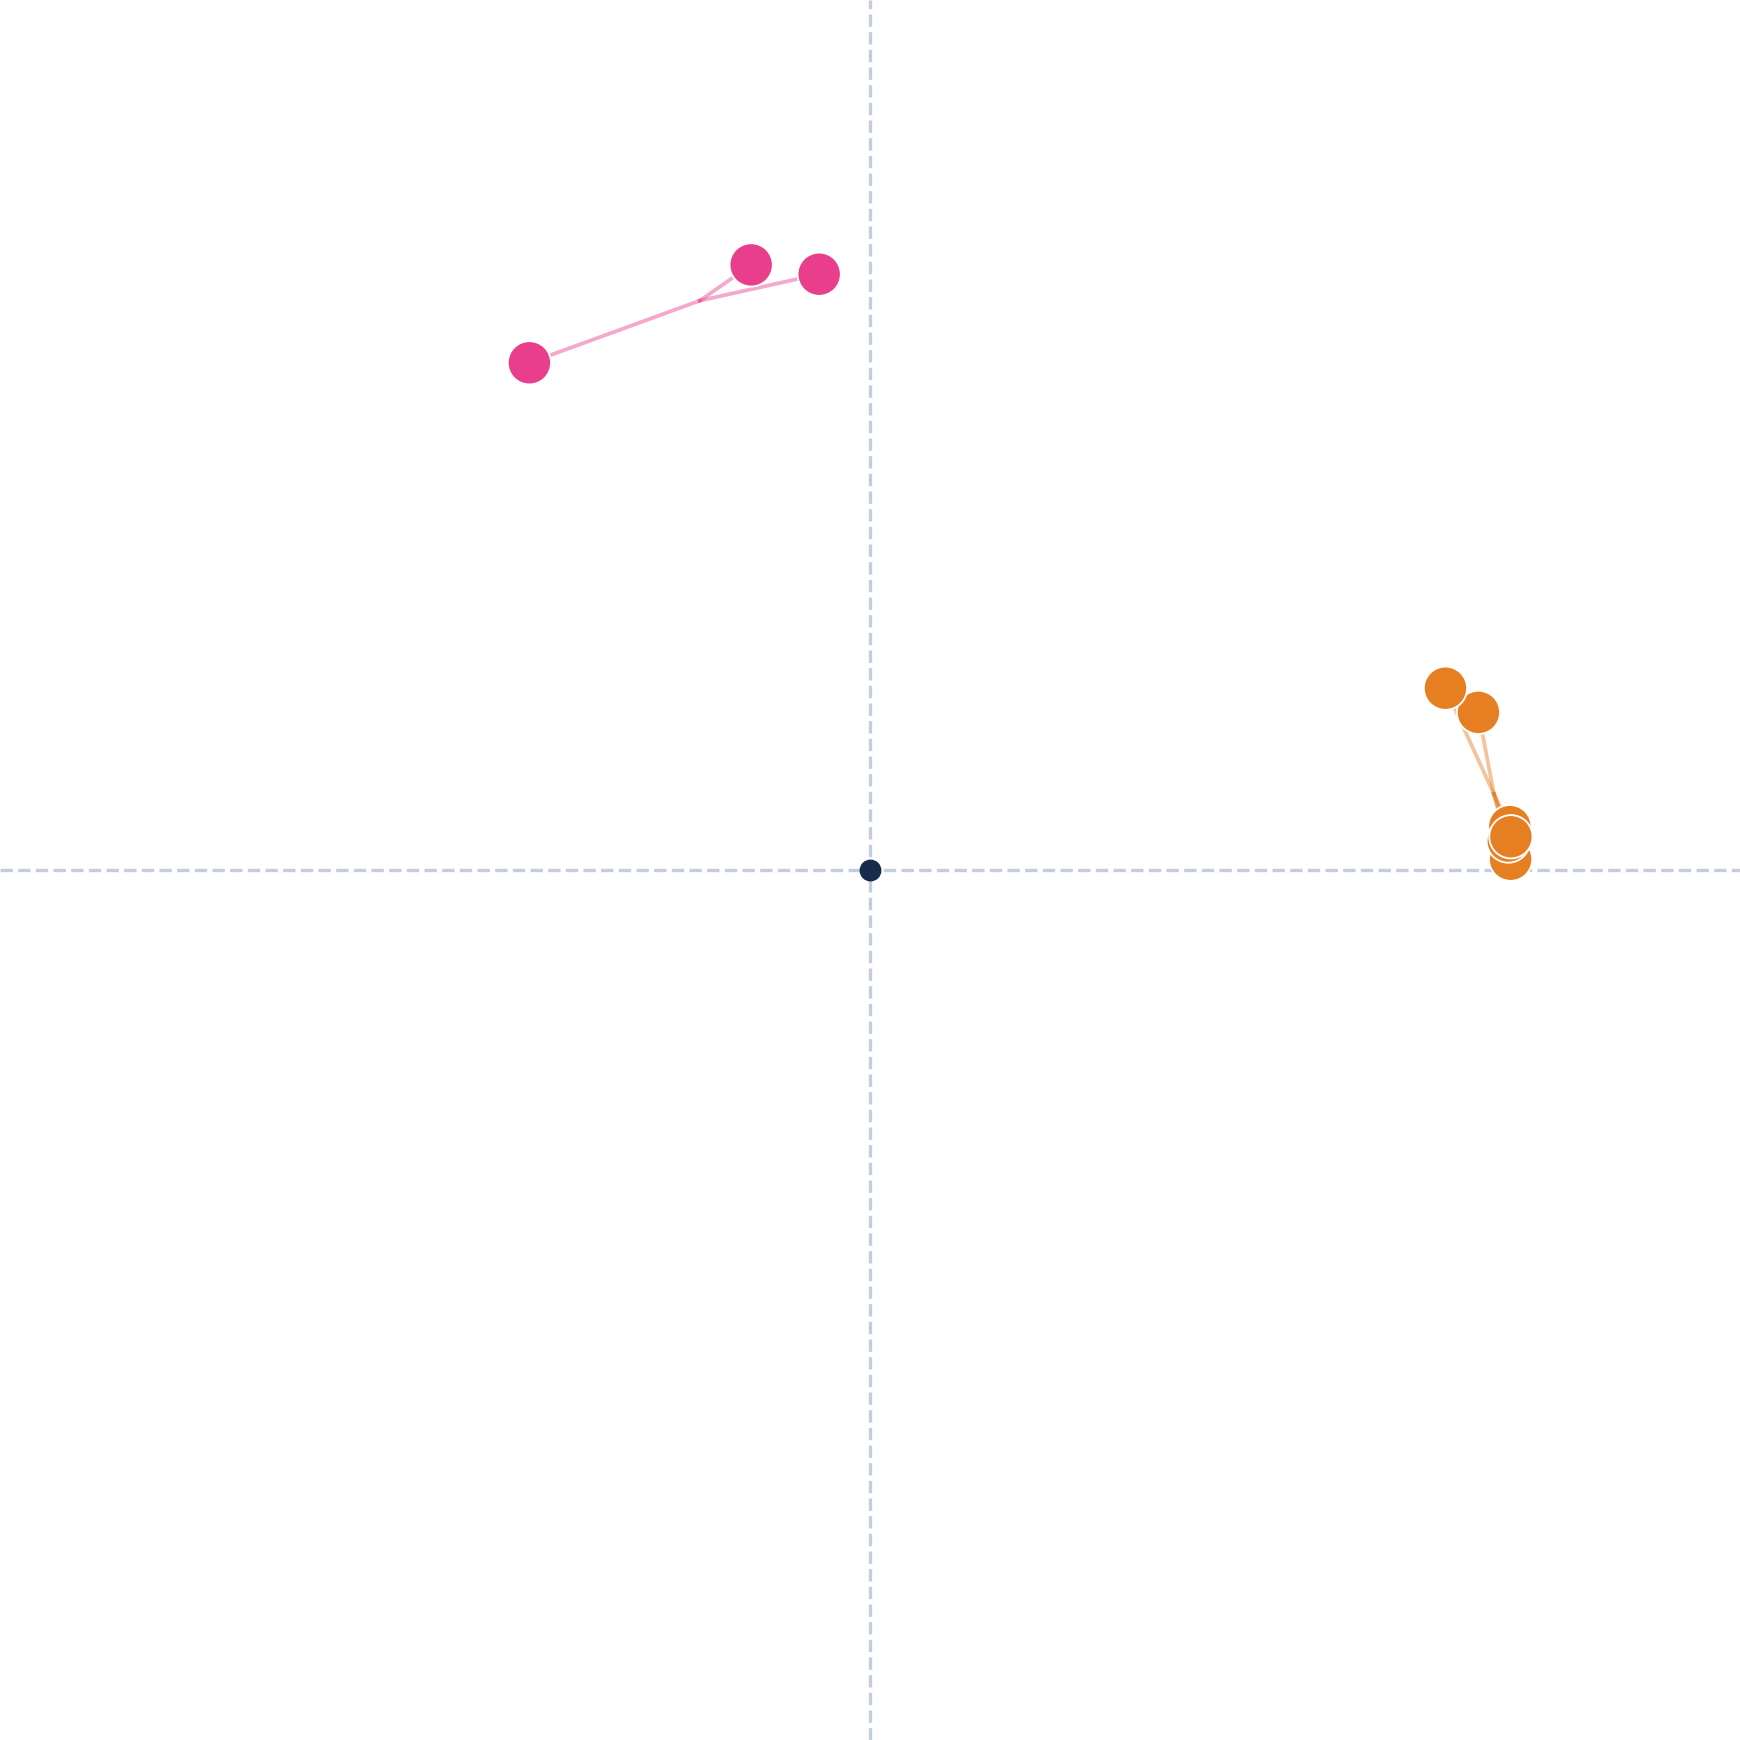

### oneD_diffuse — feature 59154

Retained contexts: 64 · median effect magnitude: 94.65

**Murano rerender — sphere surface**

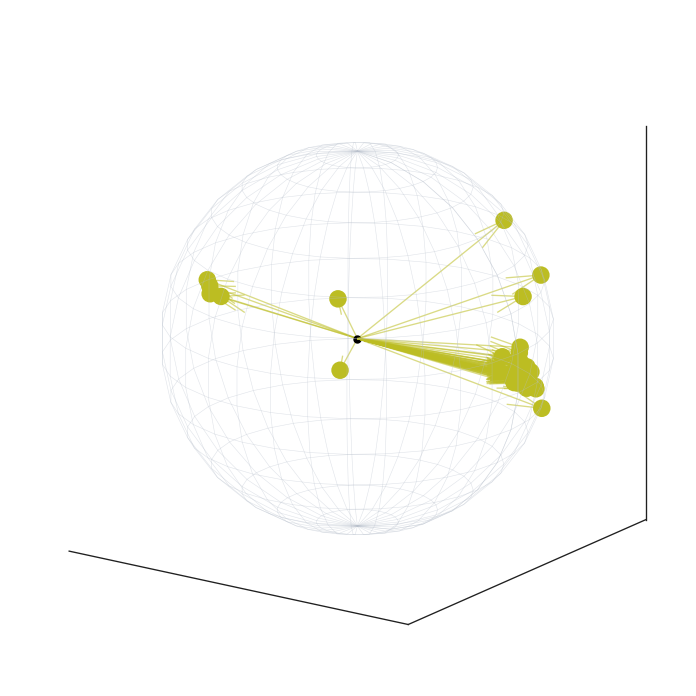

**Source reference — sphere surface**

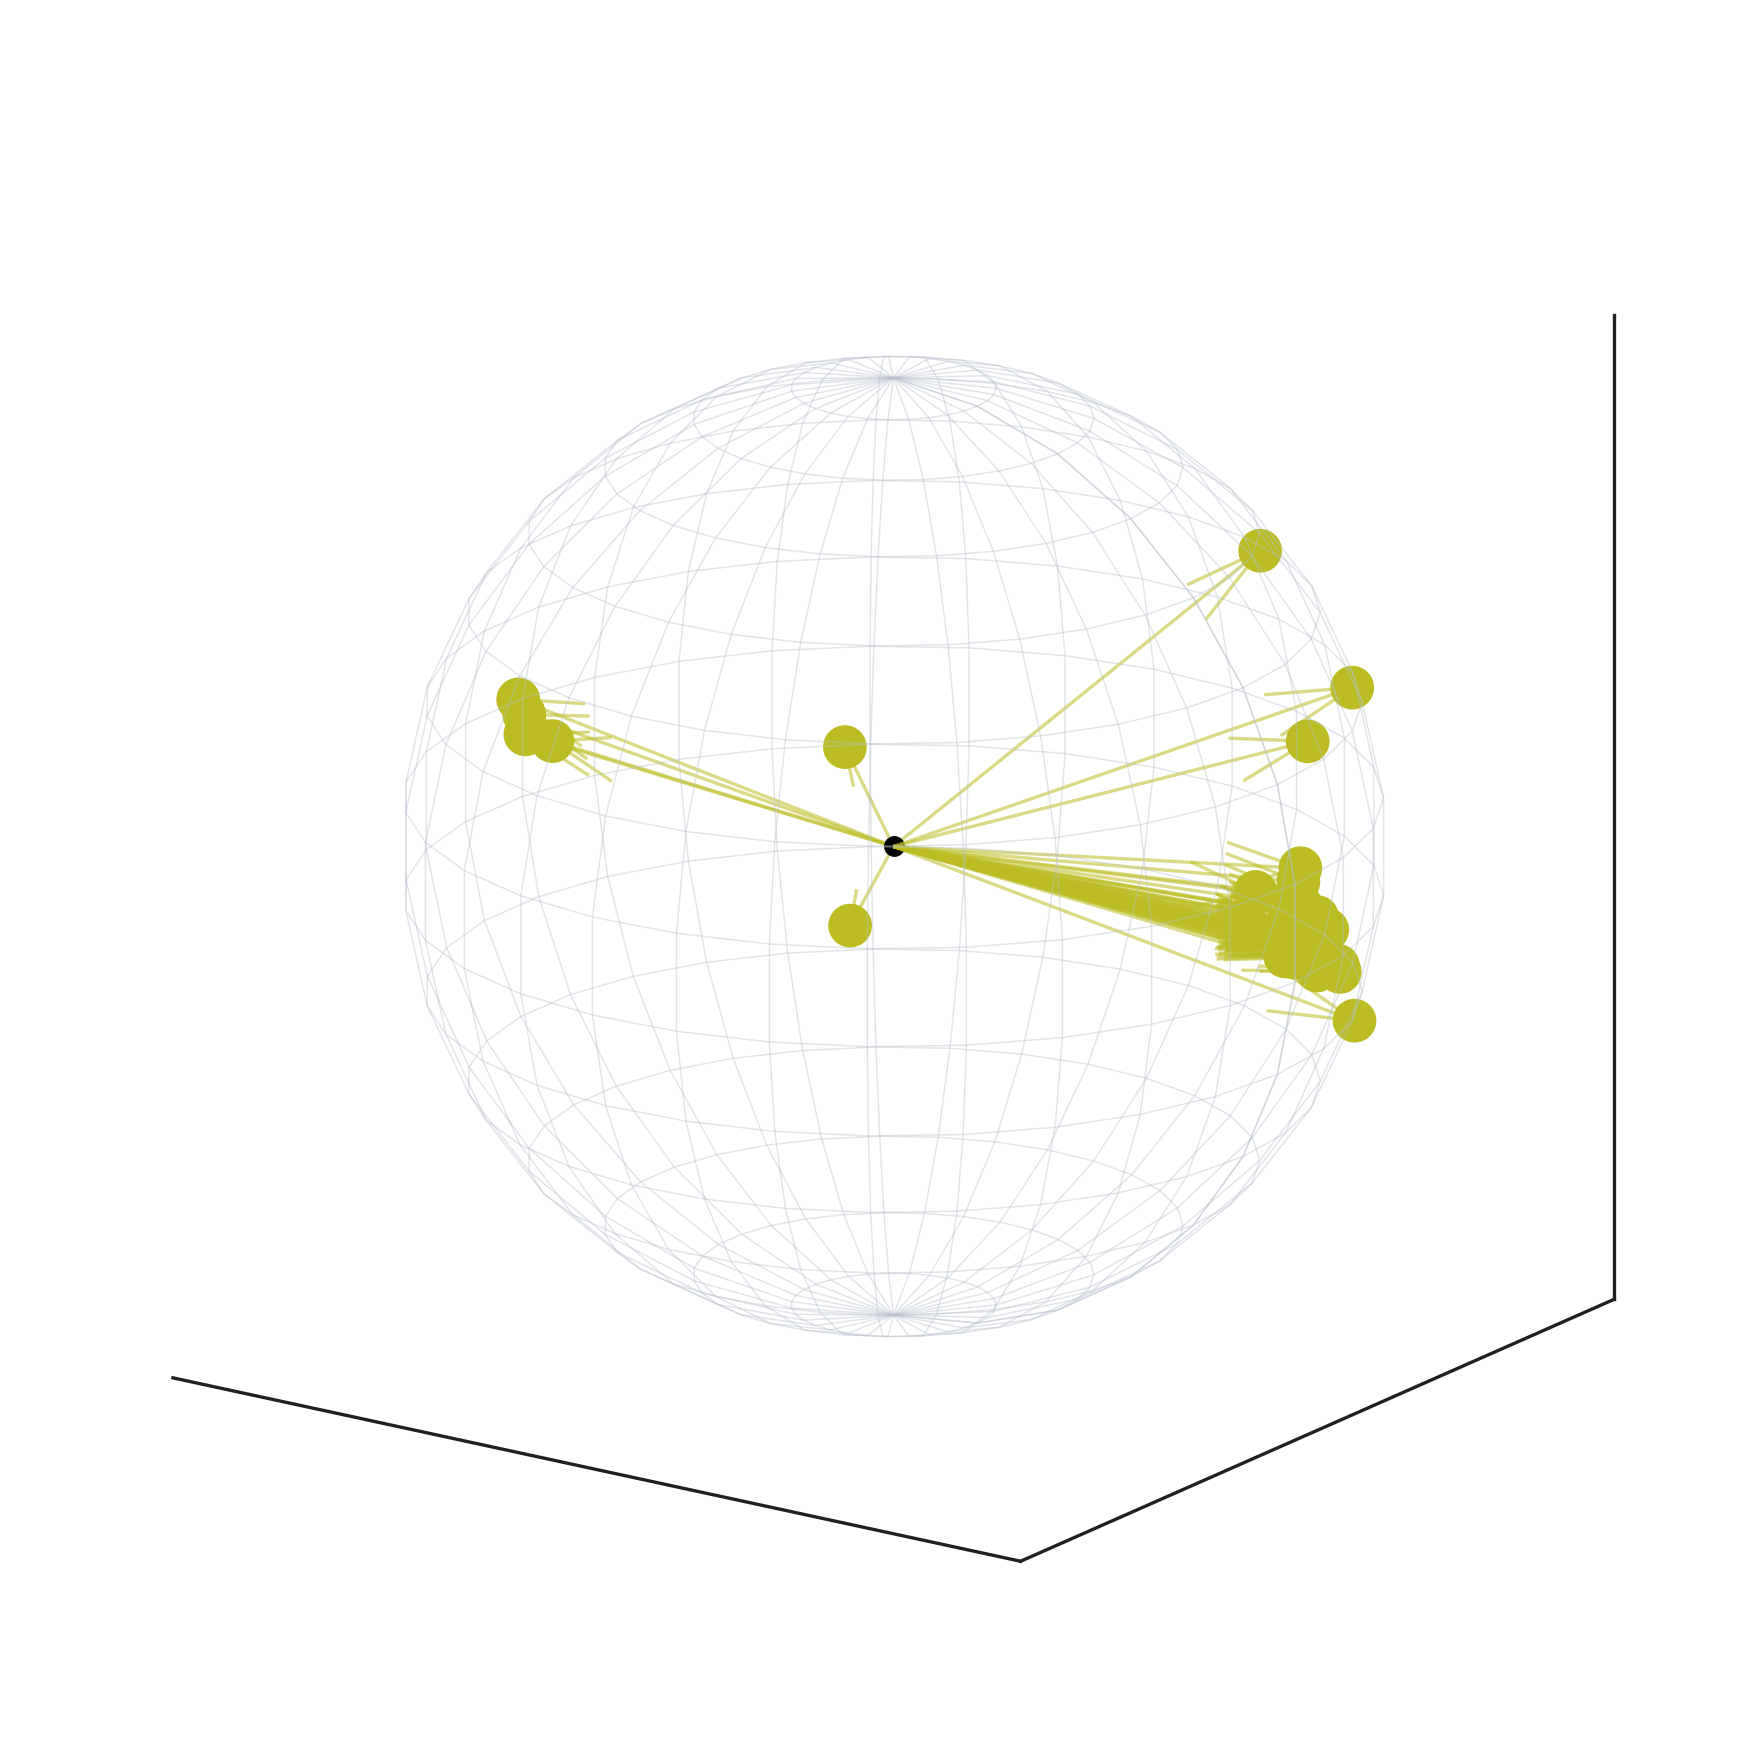

**Murano rerender — family projection**

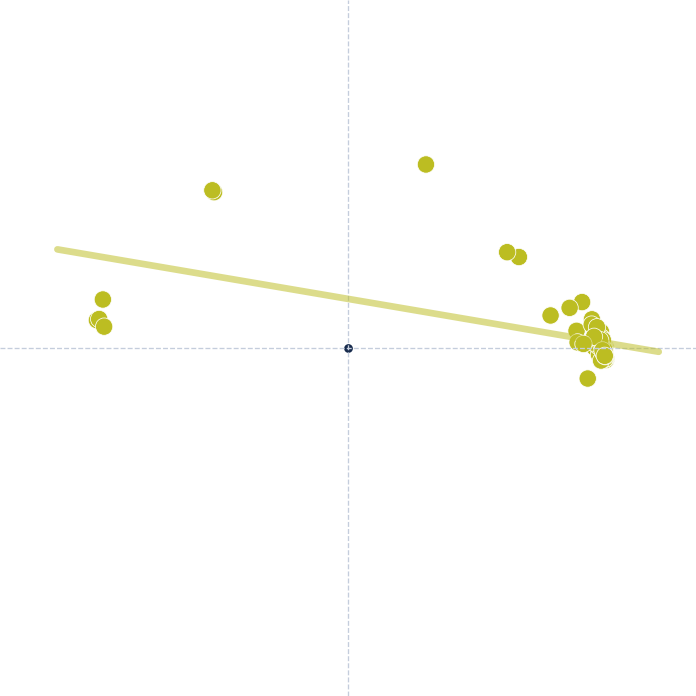

**Source reference — family projection**

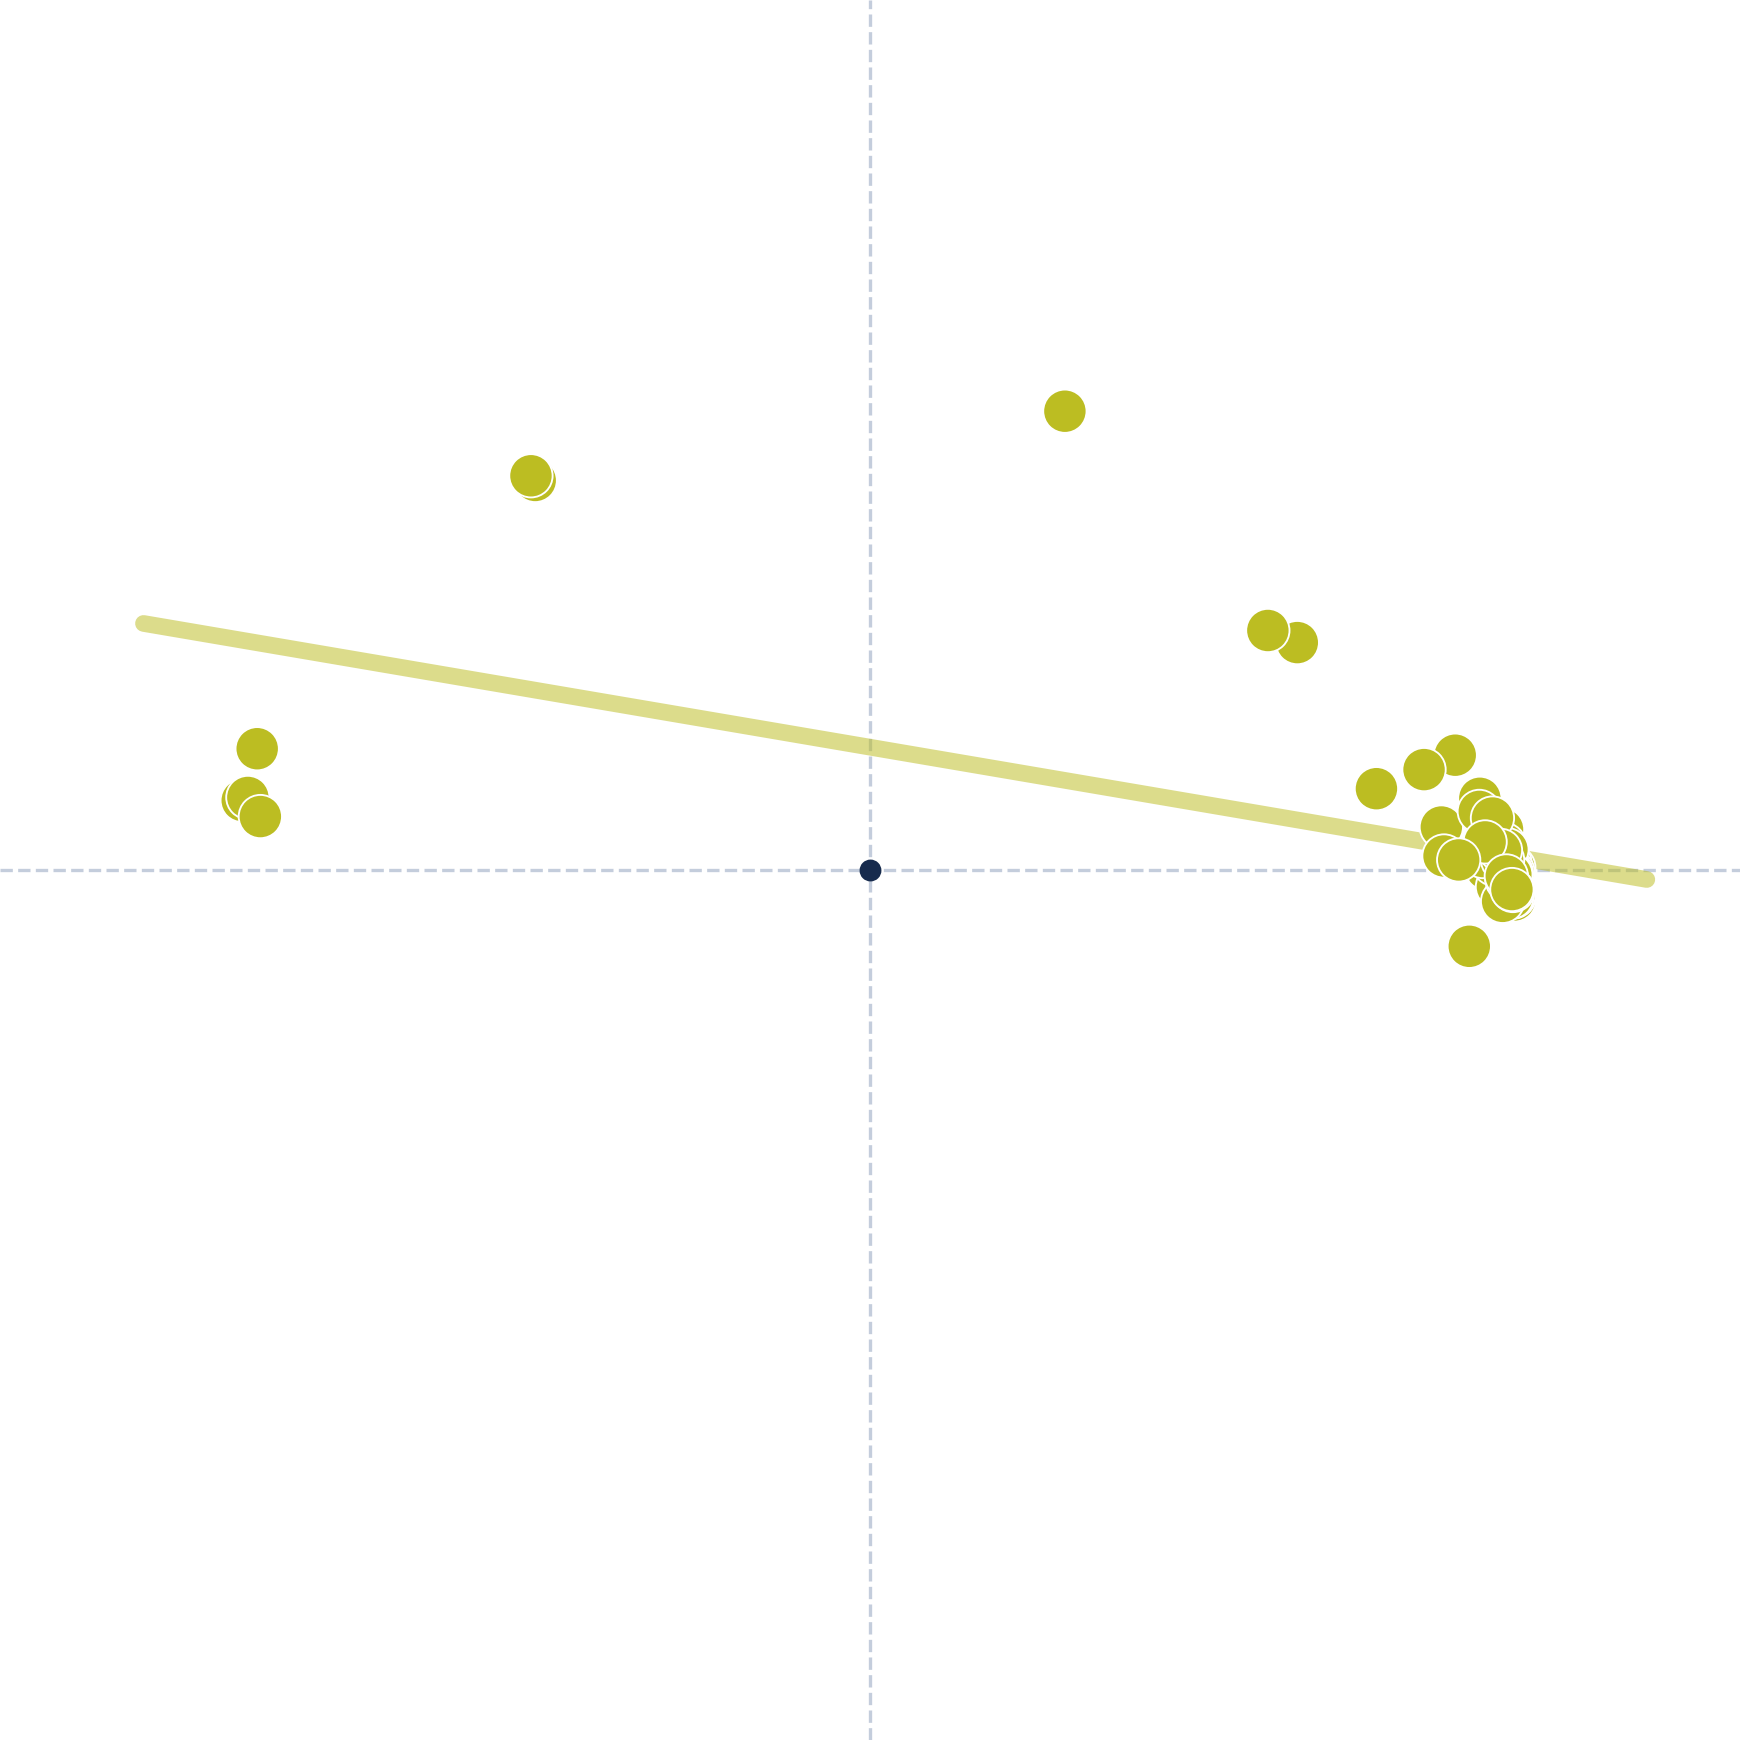

### residual_lowD_k — feature 19224

Retained contexts: 64 · median effect magnitude: 63.77

**Murano rerender — sphere surface**

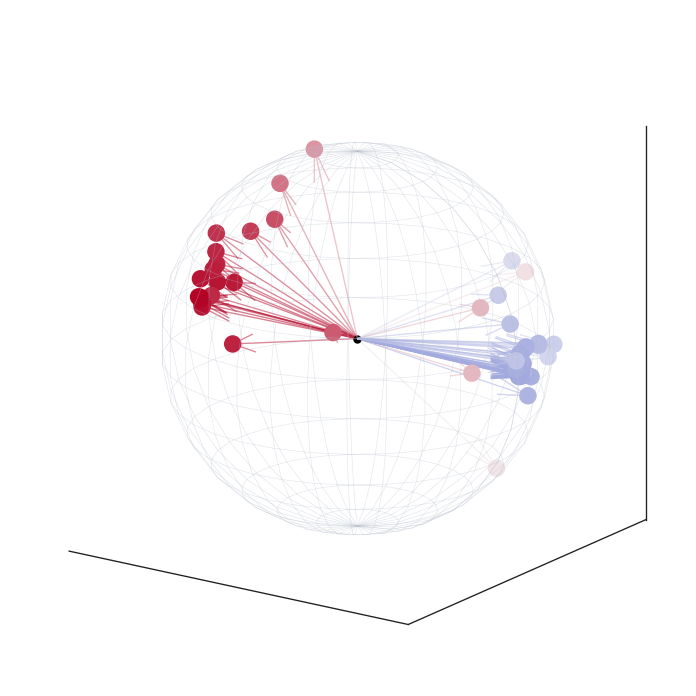

**Source reference — sphere surface**

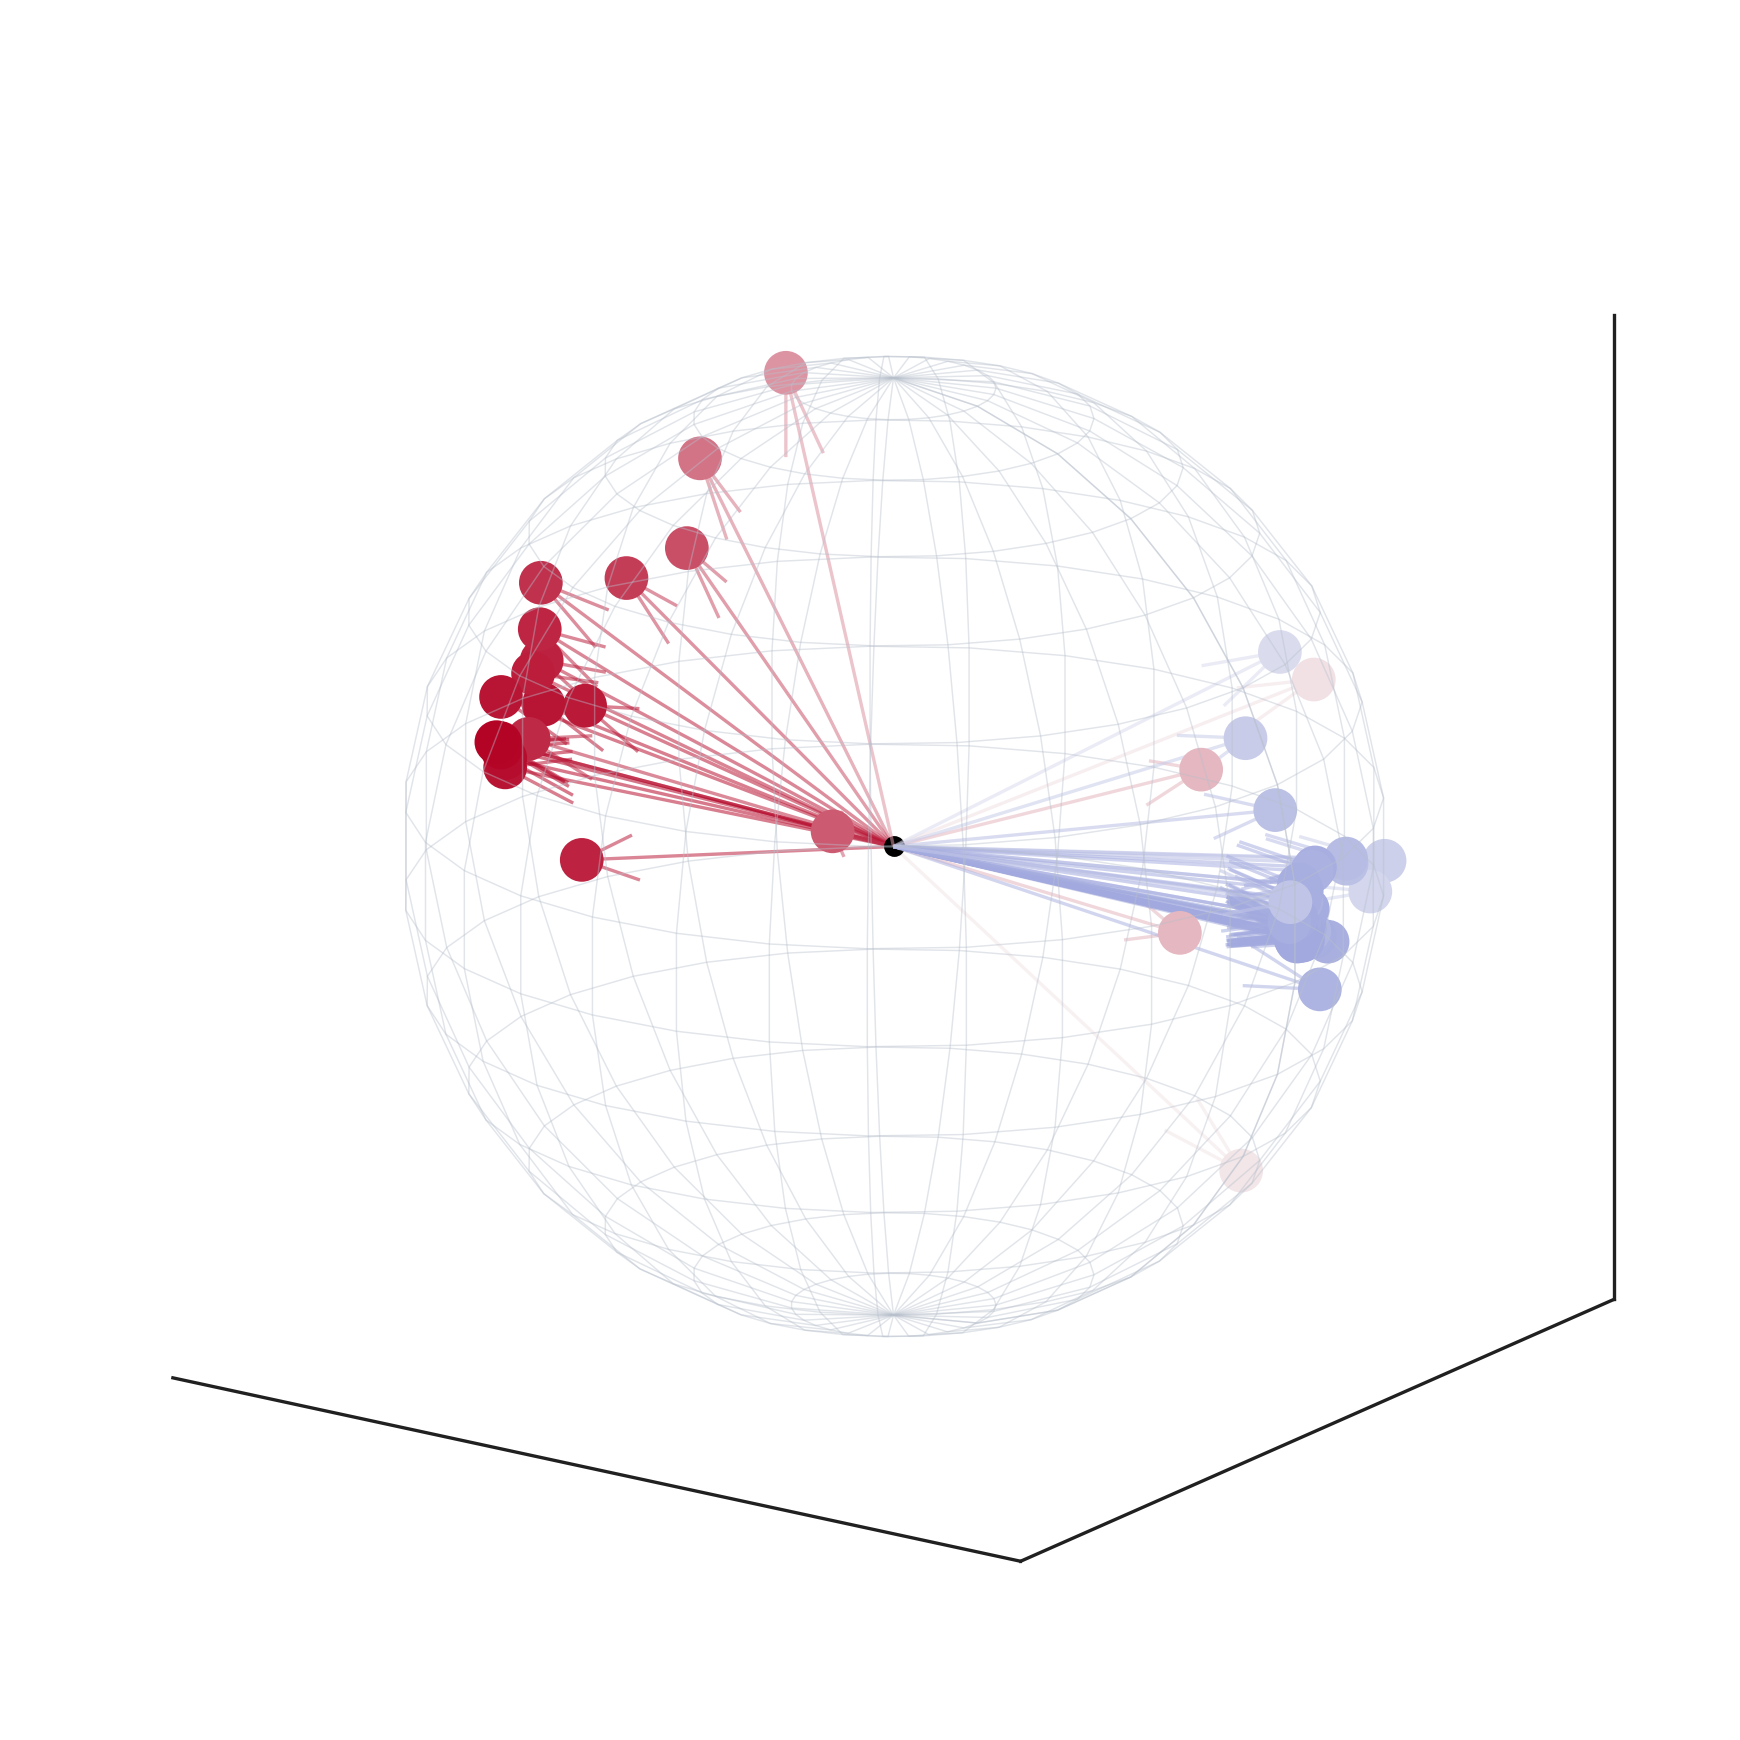

**Murano rerender — family projection**

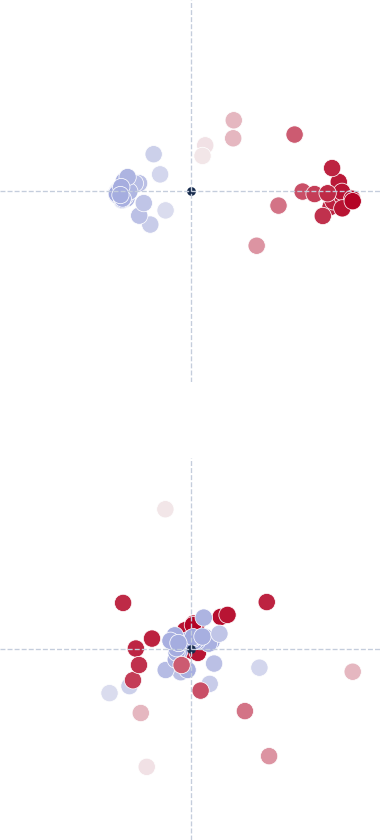

**Source reference — family projection**

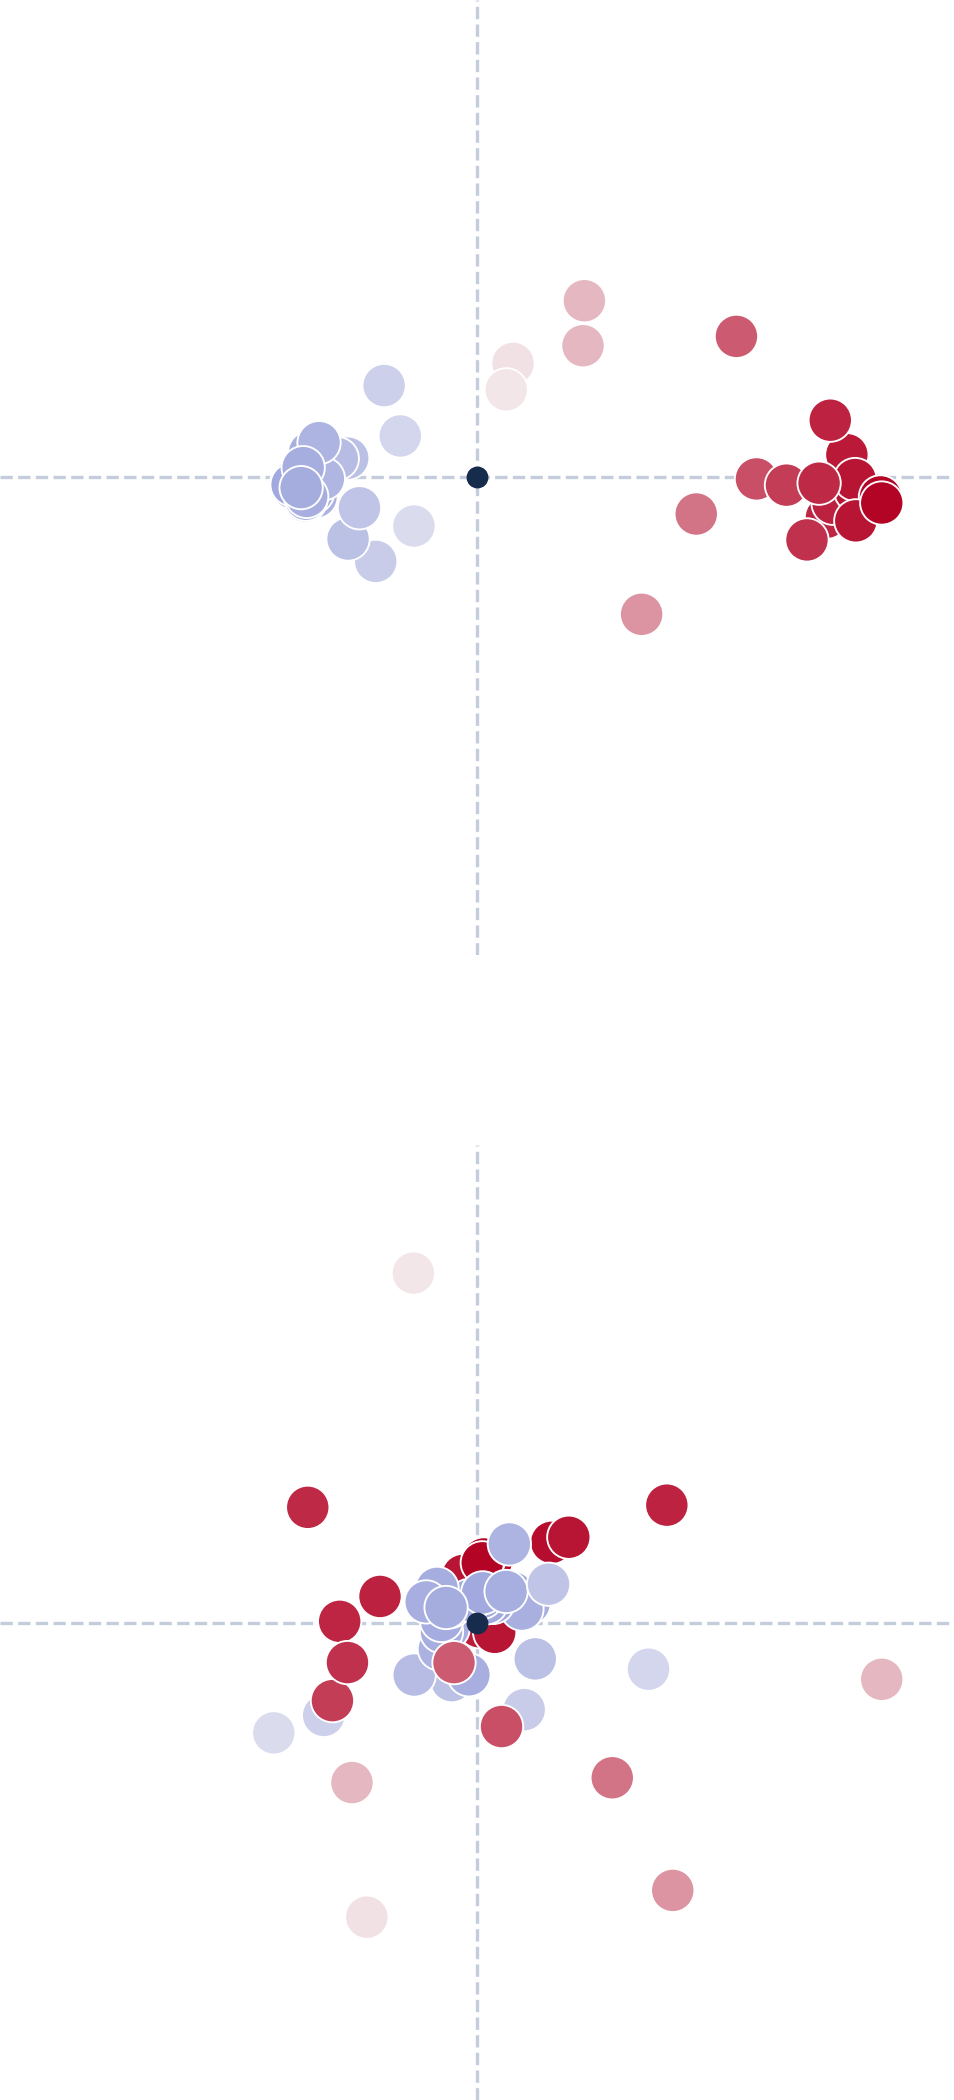

### unresolved_high_dimensional_or_diffuse — feature 34636

Retained contexts: 64 · median effect magnitude: 36.41

**Murano rerender — sphere surface**

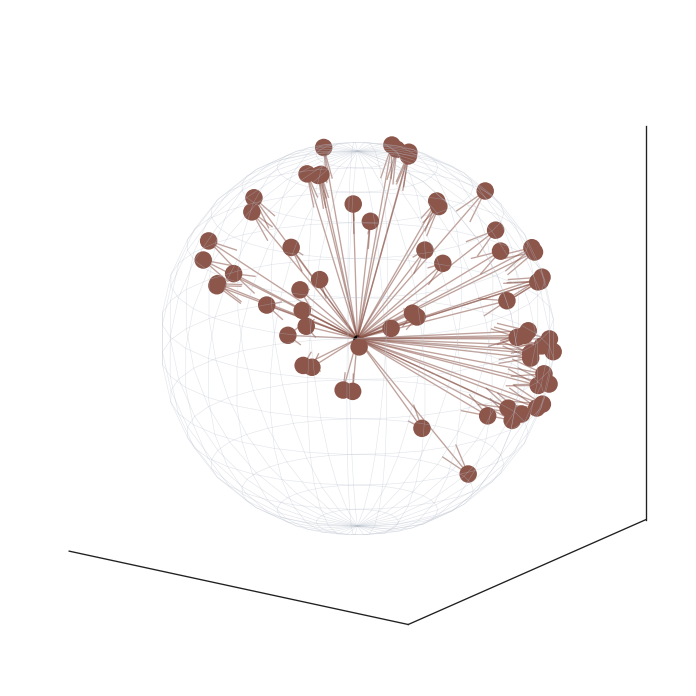

**Source reference — sphere surface**

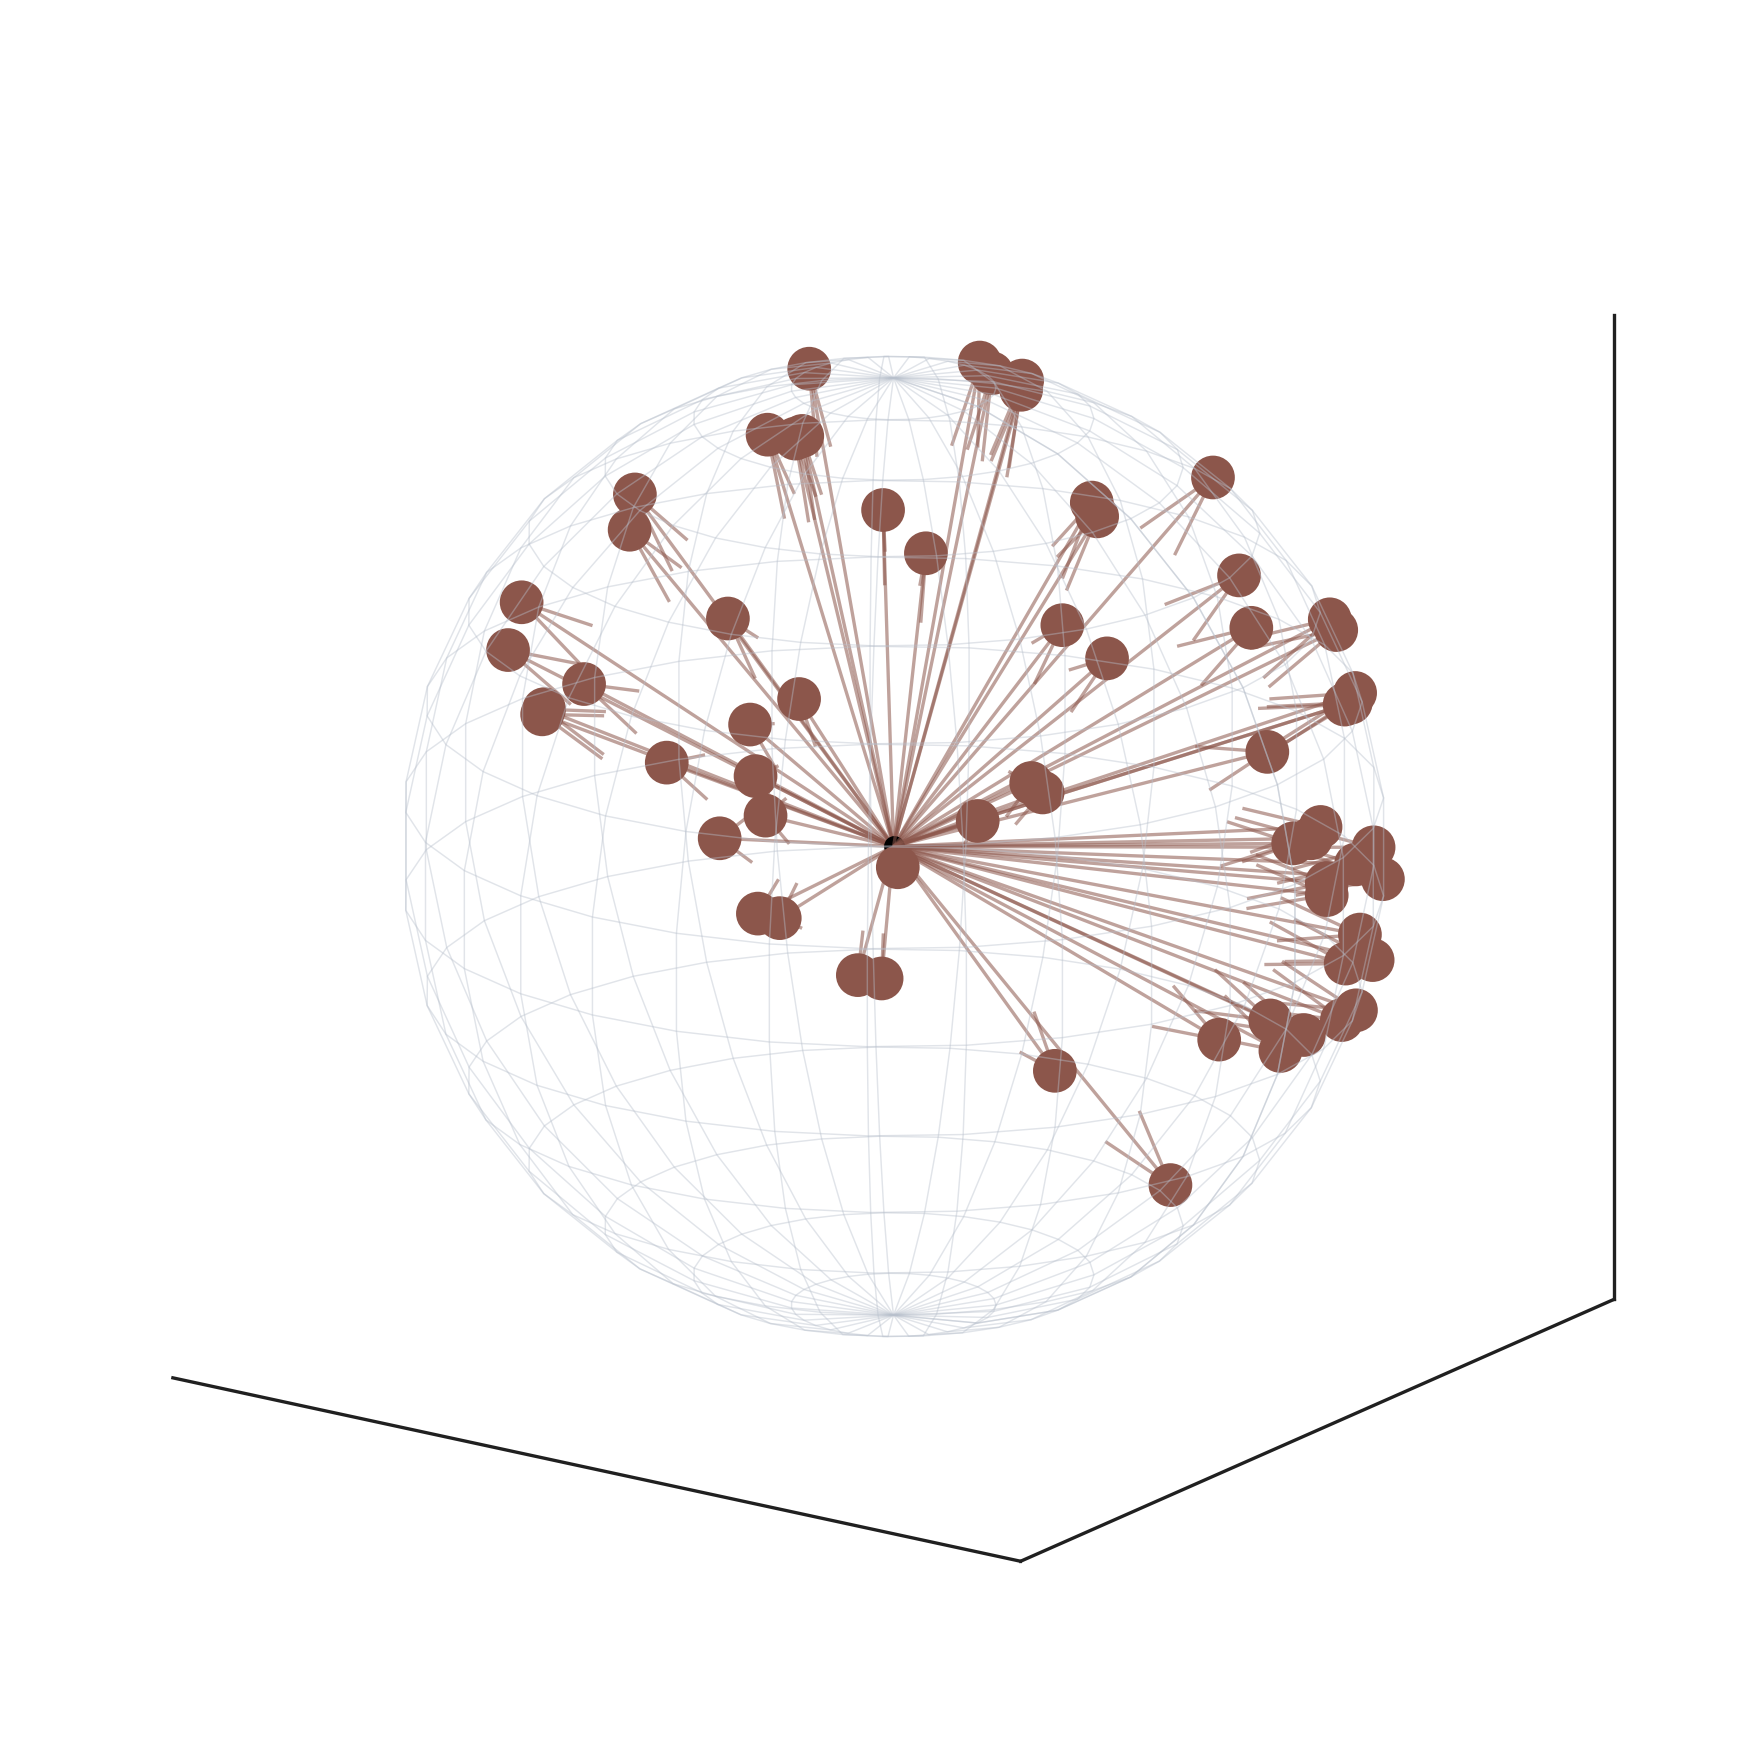

**Murano rerender — family projection**

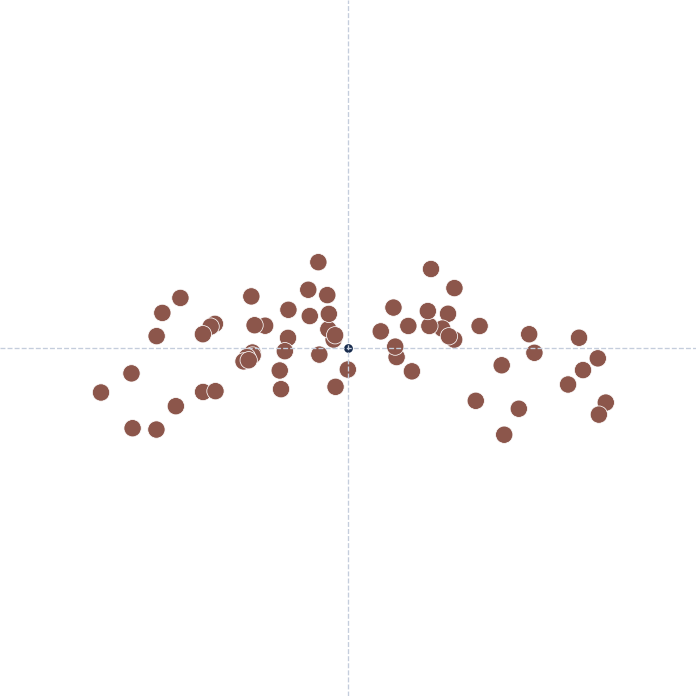

**Source reference — family projection**

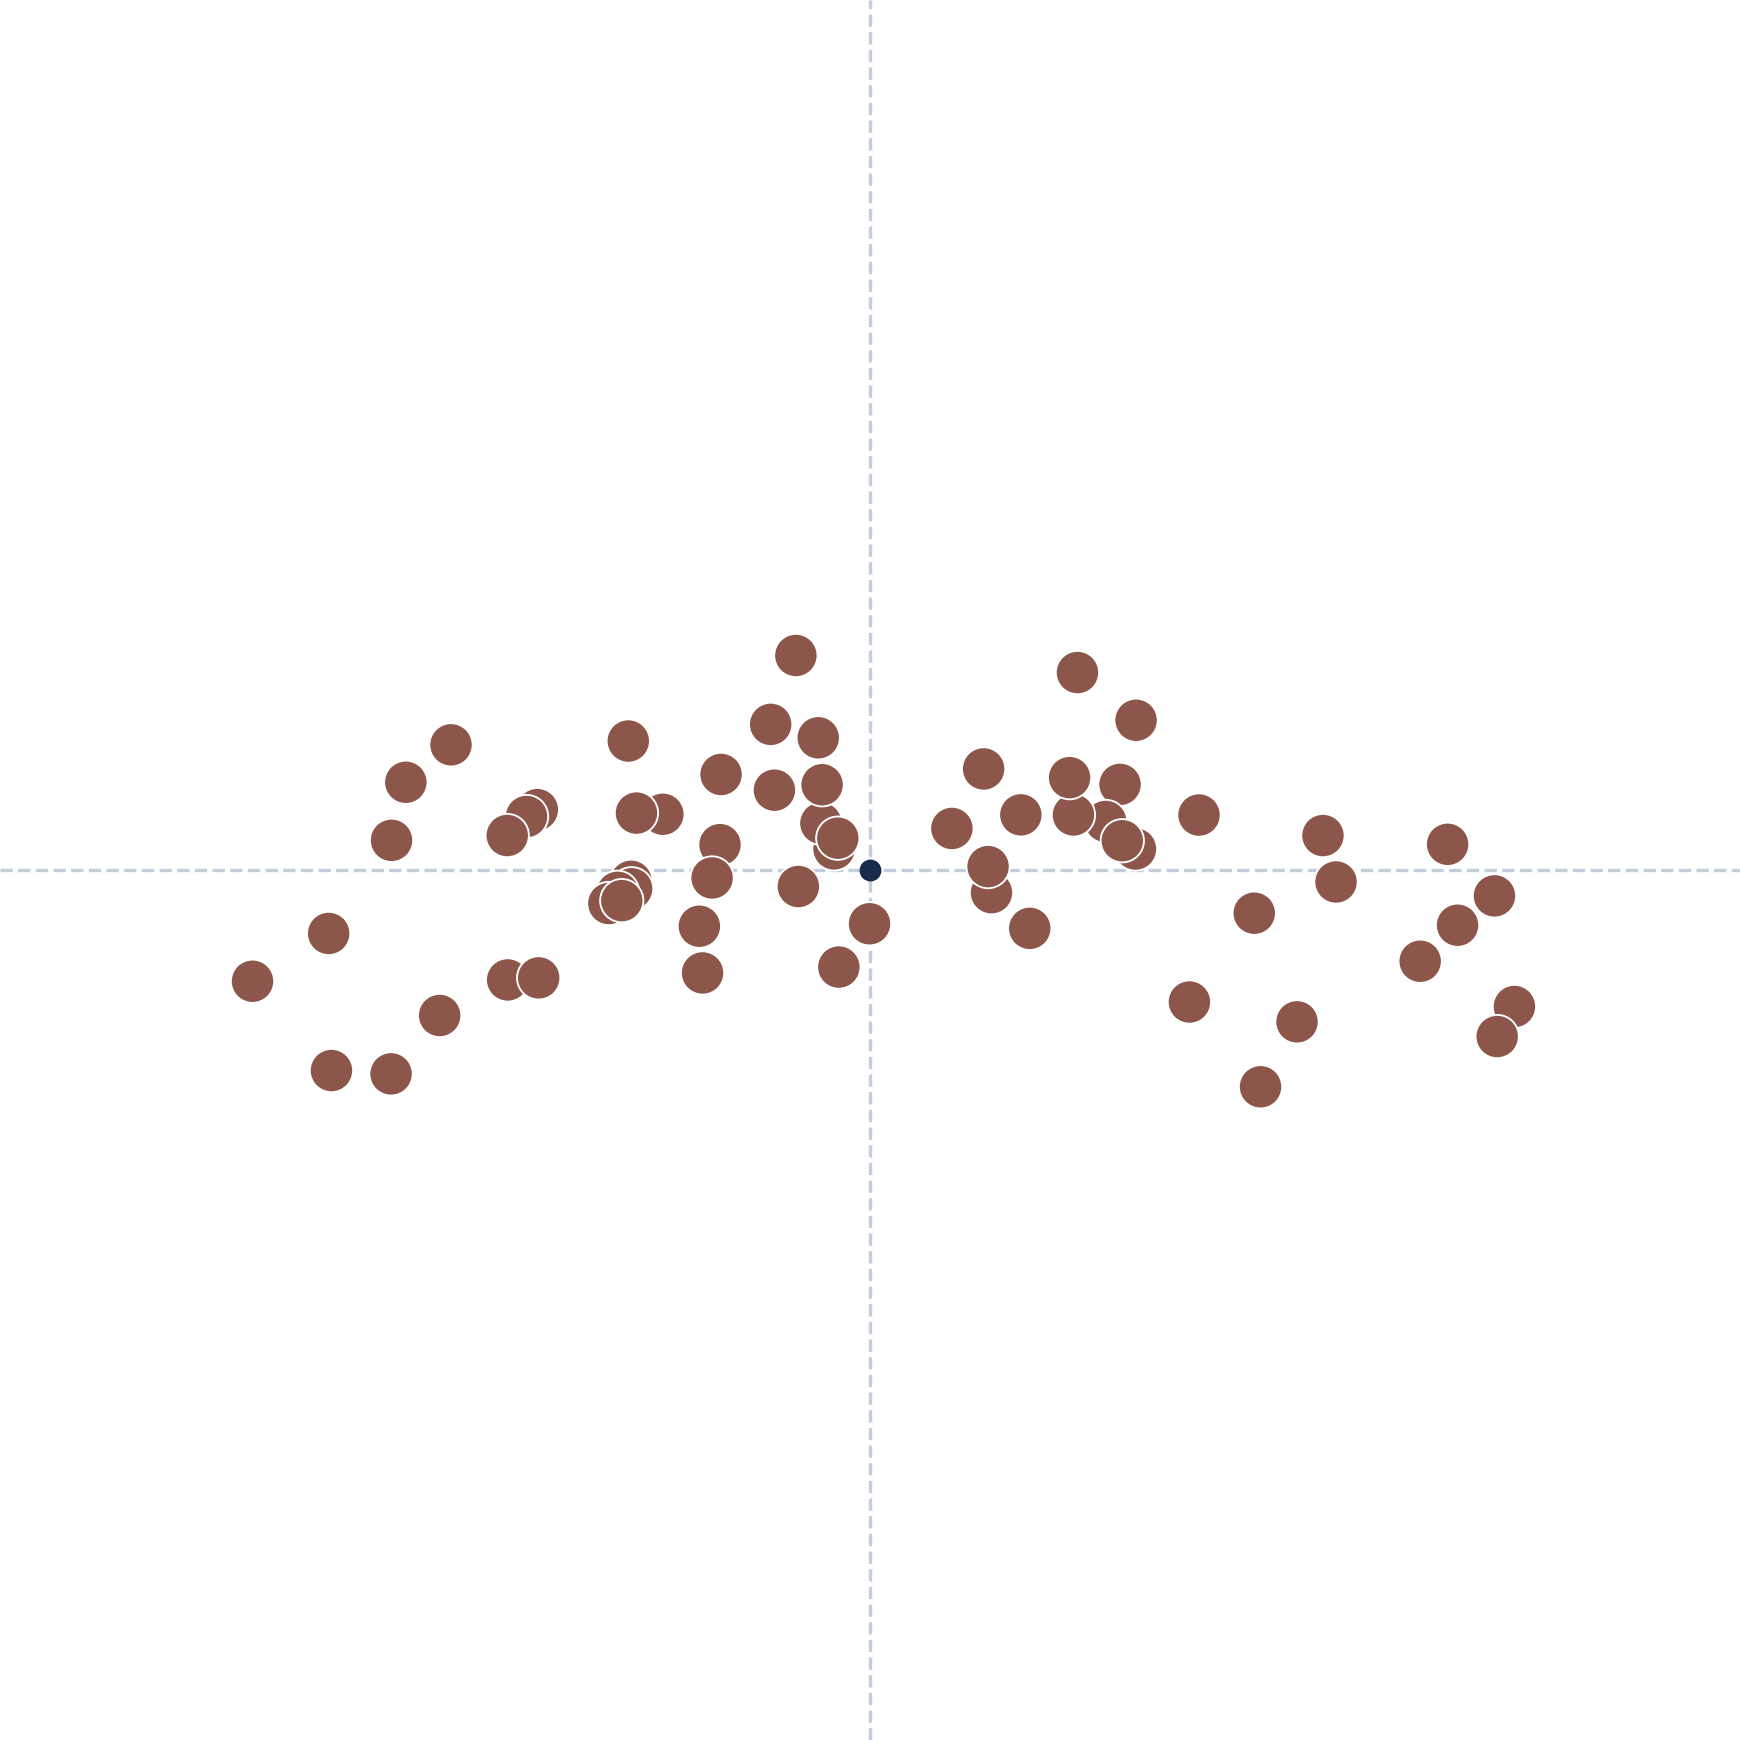

In [6]:
artifact_root = Path("notebooks/reproductions/artifacts/hoang2026_fega")
if not artifact_root.exists():
    artifact_root = Path("artifacts/hoang2026_fega")
if not artifact_root.exists():
    raise FileNotFoundError("Committed FEGA reference artifacts are missing")

reference_index = json.loads((artifact_root / "index.json").read_text())
atlas_payload = json.loads((artifact_root / "atlas.json").read_text())
reference_directory = tempfile.TemporaryDirectory(prefix="murano-fega-reference-")
rerender_root = Path(reference_directory.name)
reference_rerenders = []
source_reference_files = []

atlas_records = [
    {"primary_label": row["label"], "m_median": row["m_median"]}
    for row in atlas_payload["features"]
]
atlas_coordinates = np.asarray(
    [[row["x"], row["y"]] for row in atlas_payload["features"]],
    dtype=np.float64,
)
murano_atlas = rerender_root / "geometry_atlas.png"
source_atlas = artifact_root / "geometry_atlas.png"
render_atlas(murano_atlas, atlas_records, atlas_coordinates, dpi=120)
reference_rerenders.append(murano_atlas)
source_reference_files.append(source_atlas)
display(Markdown("### Geometry atlas — Murano rerender"))
display(Image(filename=str(murano_atlas)))
display(Markdown("**Source reference**"))
display(Image(filename=str(source_atlas)))

for candidate in reference_index["candidates"]:
    root = artifact_root / candidate["path"]
    metadata = json.loads((root / "metadata.json").read_text())
    with np.load(root / "geometry.npz", allow_pickle=False) as archive:
        kernel = np.array(archive["kernel"], copy=True)
        sphere = np.array(archive["sphere_coordinates"], copy=True)
        plane = np.array(archive["projection_2d"], copy=True)
        magnitudes = np.array(archive["magnitudes"], copy=True)
        assignments = np.array(archive["hard_assignments"], copy=True)
    assert kernel.shape == (len(sphere), len(sphere))

    family = candidate["family"]
    color = CLASS_PALETTE[family]
    point_colors = None
    mode_assignments = None
    if family == "axis_or_antipodal":
        point_colors = [
            "#4F6D8A" if value < 0 else "#C7444E" if value > 0 else "#333333"
            for value in sphere[:, 0]
        ]
    elif family == "residual_lowD_k":
        point_colors = residual_point_colors(plane[:, 0].tolist())
    elif family == "multi_mode_directional_geometry":
        mode_assignments = assignments.astype(int).tolist()
        palette = ("#E83E8C", "#E67E22", "#2A9D8F", "#6C5CE7")
        modes = sorted(
            set(mode_assignments),
            key=lambda mode: (
                float(sphere[assignments == mode, 0].mean()),
                float(sphere[assignments == mode, 1].mean()),
                mode,
            ),
        )
        color_by_mode = {mode: palette[index] for index, mode in enumerate(modes)}
        point_colors = [color_by_mode[mode] for mode in mode_assignments]

    surface, keep = surface_coordinates(sphere)
    surface_colors = (
        [
            point_color
            for point_color, retained in zip(point_colors, keep, strict=True)
            if retained
        ]
        if point_colors is not None
        else None
    )
    output_root = rerender_root / candidate["path"]
    output_root.mkdir(parents=True, exist_ok=True)
    murano_sphere = output_root / "sphere_surface.png"
    murano_projection = output_root / "projection_2d.png"
    render_sphere_surface(
        murano_sphere, surface, color=color, dpi=120, point_colors=surface_colors
    )
    if family == "residual_lowD_k":
        render_residual_view(
            murano_projection,
            plane,
            selected_k=int(
                metadata["source_metrics"]["projection"]["residual_selected_k"]
            ),
            color=color,
            dpi=120,
            point_colors=point_colors,
        )
    elif family == "global_2D_directional_subspace":
        render_subspace_plane(
            murano_projection, sphere, color=color, dpi=120, point_colors=point_colors
        )
    else:
        render_projection_2d(
            murano_projection,
            plane,
            color=color,
            dpi=120,
            point_colors=point_colors,
            axis_guide=family == "axis_or_antipodal",
            view_padding=2.4 if family == "directed_ray" else 1.35,
            primary_axis_guide=family
            not in {
                "multi_mode_directional_geometry",
                "oneD_diffuse",
                "unresolved_high_dimensional_or_diffuse",
            },
            view_limit=1.35 if family == "multi_mode_directional_geometry" else None,
            mode_assignments=mode_assignments,
            fitted_line=family == "oneD_diffuse",
        )

    source_sphere = root / "sphere_surface.png"
    source_projection = root / "projection_2d.png"
    reference_rerenders.extend((murano_sphere, murano_projection))
    source_reference_files.extend((source_sphere, source_projection))
    suffix = (
        " — Matryoshka supplement"
        if candidate["source_tag"] == "matryoshka_multi_mode_supplement"
        else ""
    )
    display(
        Markdown(
            f"### {family} — feature {candidate['feature_id']}{suffix}\n\n"
            f"Retained contexts: {len(sphere)} · median effect magnitude: {np.median(magnitudes):.4g}"
        )
    )
    display(Markdown("**Murano rerender — sphere surface**"))
    display(Image(filename=str(murano_sphere)))
    display(Markdown("**Source reference — sphere surface**"))
    display(Image(filename=str(source_sphere)))
    display(Markdown("**Murano rerender — family projection**"))
    display(Image(filename=str(murano_projection)))
    display(Markdown("**Source reference — family projection**"))
    display(Image(filename=str(source_projection)))

## 6. Scope of the result

The live section establishes that Murano can execute all six FEGA analysis phases plus visualization on this 24-prompt authored population and render its result. Its `directed_ray` conclusion applies only to feature 19403 on these prompts. The compact section separately establishes that Murano can consume exported source geometry and rerender the approved atlas, sphere-surface, and family-projection views.

The notebook does **not** rerun the paper's RAVEL/ICL datasets, feature selection, aggregate analyses, or model/SAE sweep. It is also not the source-faithfulness proof: maintainer-only same-input comparisons use the external source implementation and cached runs in place and remain outside the notebook and Git.

In [7]:
missing_phases = [name for name, key in phase_keys.items() if key not in results]
assert not missing_phases, f"Missing FEGA phases: {missing_phases}"
assert len(prep.selected_context_indices[FEATURE_ID]) == len(prompts) == 24
assert len(feature_effects.context_indices) == len(prompts)
assert classification.primary_label
assert live_summary_rows and geometry_summary_rows and decision_summary_rows
rendered_names = {path.name for path in live_files}
assert {
    "geometry_atlas.png",
    "sphere_surface.png",
    "projection_2d.png",
} <= rendered_names
assert len(reference_index["candidates"]) == 8
assert len(reference_rerenders) == 17
assert len(source_reference_files) == 17
assert all(path.is_file() and path.stat().st_size > 0 for path in reference_rerenders)
assert all(
    path.is_file() and path.stat().st_size > 0 for path in source_reference_files
)
assert all(candidate["source_tag"] for candidate in reference_index["candidates"])

reference_directory.cleanup()
live_directory.cleanup()
print("FEGA_NOTEBOOK_OK")

FEGA_NOTEBOOK_OK
